# Notebook Classification

In aceasta parte a temei, partea de clasificare va fi facuta pe un dataset cu meciuri de fotbal din Anglia. Contine mai multe meciuri, din mai multi ani, inclusiv anii 90'. Scopul e sa facem o clasificare, sa stim tipul de rezultat final dintre 2 echipe din Premier League.

Link-ul de unde se poate gasi acest dataset este : https://www.kaggle.com/datasets/panaaaaa/english-premier-league-and-championship-full-dataset/data?select=England+CSV.csv

- Contine mai multe date, cum ar fi : data, sezon, cartonare rosii, galbene, fault-uri, cornere, etc. . Totusi, pe unele dintre ele, cum ar fi nr de cartonase, nu avem cum sa le cunoastem de dinainte.
- O metoda de optimizare, este de ex. sa luam media faulturilor sau cartonaselor rosii. De exemplu, daca media cartonaselor rosii din ultimele 5 meciuri e mare atunci exista o tendinta sa piarda acel meci, deoarece exista o probabilitate mare sa ia echipa respectiva un cartonas rosu.
- Coloana pe care dorim sa o prezicem este : ***FT Result***

Astfel, in urma acestui notebook, vom afla top 5 modele de ML care prezic cel mai bun rezultat.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
%load_ext autoreload
%autoreload 2

df = pd.read_csv('../Datasets/England CSV.csv')
print(f'Shape: {df.shape}')

Shape: (12153, 25)


#### Coloanele:

In [2]:
df.columns

Index(['Date', 'Season', 'HomeTeam', 'AwayTeam', 'FTH Goals', 'FTA Goals',
       'FT Result', 'HTH Goals', 'HTA Goals', 'HT Result', 'Referee',
       'H Shots', 'A Shots', 'H SOT', 'A SOT', 'H Fouls', 'A Fouls',
       'H Corners', 'A Corners', 'H Yellow', 'A Yellow', 'H Red', 'A Red',
       'Display_Order', 'League'],
      dtype='str')

#### Tipurile de date pentru fiecare coloana:
- putem observa ca unele tipuri de date au si null, deoarece nu sunt 12153, ci mai putine.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12153 entries, 0 to 12152
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           12153 non-null  str    
 1   Season         12153 non-null  str    
 2   HomeTeam       12153 non-null  str    
 3   AwayTeam       12153 non-null  str    
 4   FTH Goals      12153 non-null  int64  
 5   FTA Goals      12153 non-null  int64  
 6   FT Result      12153 non-null  str    
 7   HTH Goals      11229 non-null  float64
 8   HTA Goals      11229 non-null  float64
 9   HT Result      11229 non-null  str    
 10  Referee        9329 non-null   str    
 11  H Shots        9329 non-null   float64
 12  A Shots        9329 non-null   float64
 13  H SOT          9329 non-null   float64
 14  A SOT          9329 non-null   float64
 15  H Fouls        9329 non-null   float64
 16  A Fouls        9329 non-null   float64
 17  H Corners      9329 non-null   float64
 18  A Corners      93

In [4]:
df.head()

,Date,Season,HomeTeam,AwayTeam,FTH Goals,FTA Goals,FT Result,HTH Goals,HTA Goals,HT Result,...,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red,Display_Order,League
0,16/01/2025,2024/25,Ipswich Town,Brighton & Hove Albion,0,2,A,0.0,1.0,A,...,13.0,14.0,1.0,9.0,2.0,2.0,0.0,0.0,20250116,Premier League
1,16/01/2025,2024/25,Man United,Southampton,3,1,H,0.0,1.0,A,...,7.0,10.0,4.0,4.0,1.0,3.0,0.0,0.0,20250116,Premier League
2,15/01/2025,2024/25,Everton,Aston Villa,0,1,A,0.0,0.0,D,...,17.0,10.0,8.0,5.0,2.0,1.0,0.0,0.0,20250115,Premier League
3,15/01/2025,2024/25,Leicester,Crystal Palace,0,2,A,0.0,0.0,D,...,7.0,6.0,4.0,3.0,0.0,0.0,0.0,0.0,20250115,Premier League
4,15/01/2025,2024/25,Newcastle,Wolves,3,0,H,1.0,0.0,H,...,10.0,13.0,4.0,2.0,0.0,2.0,0.0,0.0,20250115,Premier League


### Analiza calitativa / curatarea datelor:
- se obs ca datele sunt null unde sunt meciuri de mult timp , ex din 96', cand nu se puteau colecta datele.
- in plus, pentru predictia actuala nu conteaza, nu are vreo importanta, deci vom elimina randurile acelea

In [5]:
df.isnull().sum()

Date                0
Season              0
HomeTeam            0
AwayTeam            0
FTH Goals           0
FTA Goals           0
FT Result           0
HTH Goals         924
HTA Goals         924
HT Result         924
Referee          2824
H Shots          2824
A Shots          2824
H SOT            2824
A SOT            2824
H Fouls          2824
A Fouls          2824
H Corners        2824
A Corners        2824
H Yellow         2824
A Yellow         2824
H Red            2824
A Red            2824
Display_Order       0
League              0
dtype: int64

In [6]:
df.dropna(inplace=True)
df.shape

(9329, 25)

#### Acum nu mai exista randuri cu valori null si ar fi toate date relevante

In [7]:
df.isnull().sum()

Date             0
Season           0
HomeTeam         0
AwayTeam         0
FTH Goals        0
FTA Goals        0
FT Result        0
HTH Goals        0
HTA Goals        0
HT Result        0
Referee          0
H Shots          0
A Shots          0
H SOT            0
A SOT            0
H Fouls          0
A Fouls          0
H Corners        0
A Corners        0
H Yellow         0
A Yellow         0
H Red            0
A Red            0
Display_Order    0
League           0
dtype: int64

### Acum vom renunta la coloanele care nu sunt folositoare, de exemplu: arbitrul, liga, display order , iar data o vom sterge la final.

In [8]:
df = df.drop(['Referee','League','Display_Order'],axis=1)
df.shape

(9329, 22)

# Analiza exploratorie

- dorim sa vedem cum sunt corelate datele, legaturile dintre coloane
- mai jos se vede ca echipa de acaca are o tendinta mai buna pe orice statistica, mai putin la fault uri
- deviatia standard de ajuta la goluri, deoarece datele nu sunt asa imprastiate

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
FTH Goals,9329.0,1.536178,1.305748,0.0,1.0,1.0,2.0,9.0
FTA Goals,9329.0,1.179333,1.157003,0.0,0.0,1.0,2.0,9.0
HTH Goals,9329.0,0.687641,0.835261,0.0,0.0,0.0,1.0,5.0
HTA Goals,9329.0,0.518491,0.734551,0.0,0.0,0.0,1.0,5.0
H Shots,9329.0,13.618716,5.349420,0.0,10.0,13.0,17.0,43.0
A Shots,9329.0,10.784543,4.678710,0.0,7.0,10.0,14.0,31.0
H SOT,9329.0,6.007503,3.275177,0.0,4.0,6.0,8.0,24.0
A SOT,9329.0,4.704684,2.757288,0.0,3.0,4.0,6.0,20.0
H Fouls,9329.0,11.303462,3.752442,0.0,9.0,11.0,14.0,33.0
A Fouls,9329.0,11.781113,3.931377,1.0,9.0,12.0,14.0,29.0


Asimetria este doar pozitiva pentru ca nu exista ca nr de goluri sa fie negative.

In [10]:
df.skew(numeric_only=True)

FTH Goals    0.975128
FTA Goals    1.076766
HTH Goals    1.217881
HTA Goals    1.481468
H Shots      0.642805
A Shots      0.655182
H SOT        0.823543
A SOT        0.873413
H Fouls      0.437434
A Fouls      0.406391
H Corners    0.615626
A Corners    0.737246
H Yellow     0.769340
A Yellow     0.623094
H Red        4.147739
A Red        3.337277
dtype: float64

Majoritatea echipelor de acasa castiga.Asta influenteaza mult, unde se joaca.

In [11]:
df["FT Result"].value_counts()

FT Result
H    4278
A    2738
D    2313
Name: count, dtype: int64

La pauza exista mai multe partide la un rezultat de egalitate.

In [12]:
df["HT Result"].value_counts()

HT Result
D    3818
H    3268
A    2243
Name: count, dtype: int64

Mai jos se pot observa urmatoarele :
- foarte rar conduce echipa de acasa la pauza si ea tot pierde. Adica daca away conduce la pauza, in maj cazurilor, mai bine de jumate, castiga si meciul.
- daca echipa de acasa castiga la pauza , are cele mai mari sanse sa castige meciul.
- cele mai multe sunt egaluri la pauza.
- cele mai multe victorii la final sunt la gazde.

In [13]:
pd.crosstab(df['HT Result'], df['FT Result'], margins=True)

FT Result,A,D,H,All
HT Result,,,,
A,1565,443,235,2243
D,994,1405,1419,3818
H,179,465,2624,3268
All,2738,2313,4278,9329


Grafic pentru rezultatul final, la fel ca la value_counts.

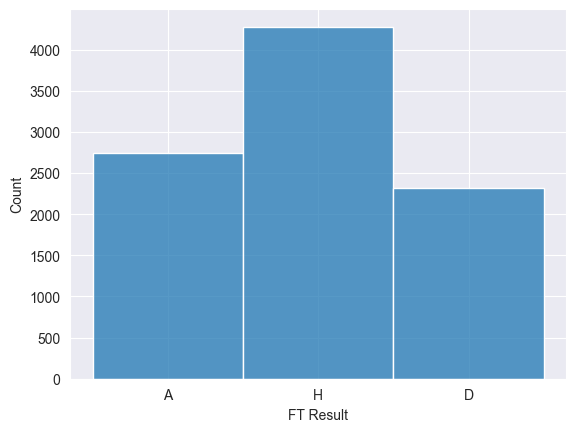

In [14]:
sns.histplot(data = df, x="FT Result")
plt.show()

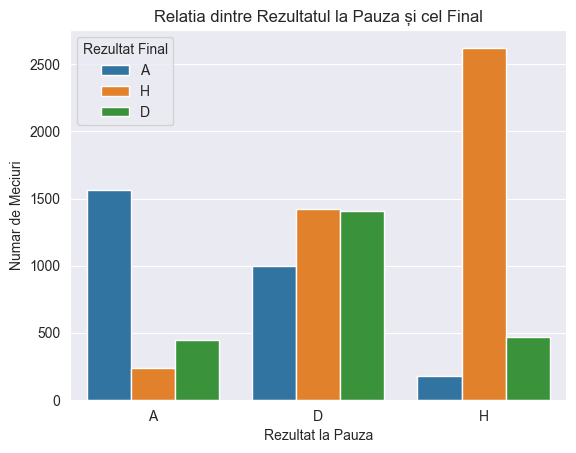

In [15]:
sns.countplot(data=df, x='HT Result', hue='FT Result')

plt.title('Relatia dintre Rezultatul la Pauza și cel Final')
plt.xlabel('Rezultat la Pauza')
plt.ylabel('Numar de Meciuri')
plt.legend(title='Rezultat Final')
plt.show()

Exista relatii intre :
- goluri si suturi
- suturi si cornere
- nr de suturi la pauza si final

<Axes: >

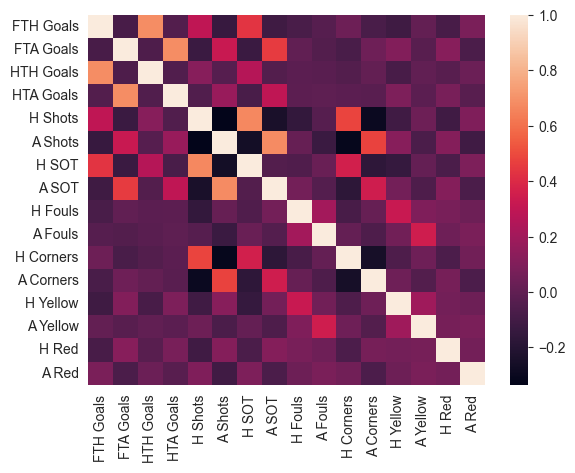

In [16]:
sns.heatmap(df.corr(numeric_only=True))

### Encodare :
- cu datele actuale nu ne putem da seama neaparat de relatii foarte specifice si vom encoda echipele, H,A,D

In [17]:
res_grid = {'H' : 0, 'D':1, 'A':2}
df['FT Result'] = df['FT Result'].str.strip()
df['HT Result'] = df['HT Result'].str.strip()
df['FT Result'] = df['FT Result'].map(res_grid)
df['HT Result'] = df['HT Result'].map(res_grid)


In [18]:
df.head(7)

,Date,Season,HomeTeam,AwayTeam,FTH Goals,FTA Goals,FT Result,HTH Goals,HTA Goals,HT Result,...,H SOT,A SOT,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red
0,16/01/2025,2024/25,Ipswich Town,Brighton & Hove Albion,0,2,2,0.0,1.0,2,...,3.0,5.0,13.0,14.0,1.0,9.0,2.0,2.0,0.0,0.0
1,16/01/2025,2024/25,Man United,Southampton,3,1,0,0.0,1.0,2,...,9.0,5.0,7.0,10.0,4.0,4.0,1.0,3.0,0.0,0.0
2,15/01/2025,2024/25,Everton,Aston Villa,0,1,2,0.0,0.0,1,...,3.0,3.0,17.0,10.0,8.0,5.0,2.0,1.0,0.0,0.0
3,15/01/2025,2024/25,Leicester,Crystal Palace,0,2,2,0.0,0.0,1,...,4.0,4.0,7.0,6.0,4.0,3.0,0.0,0.0,0.0,0.0
4,15/01/2025,2024/25,Newcastle,Wolves,3,0,0,1.0,0.0,0,...,5.0,7.0,10.0,13.0,4.0,2.0,0.0,2.0,0.0,0.0
5,15/01/2025,2024/25,Arsenal,Tottenham,2,1,0,2.0,1.0,0,...,4.0,2.0,16.0,9.0,10.0,4.0,3.0,1.0,0.0,0.0
6,14/01/2025,2024/25,Brentford,Man City,2,2,1,0.0,0.0,1,...,6.0,8.0,4.0,4.0,4.0,5.0,0.0,0.0,0.0,0.0


- pentru a codifica corect echipele si pt a avea acelasi cod si la home si la away facem un dictionar prin reuniune si apoi codificam tot

In [19]:
common_set = set(df['HomeTeam']).union(set(df['AwayTeam']))
print(common_set)

{'Brentford', 'Fulham', 'Newcastle', "Nott'm Forest", 'Middlesbrough', 'QPR', 'Leicester', 'Aston Villa', 'Wolves', 'Watford', 'Blackburn', 'Sheffield United', 'Hull', 'Chelsea', 'Bradford', 'Bolton', 'West Ham', 'Derby', 'Wigan', 'Arsenal', 'Leeds', 'Man City', 'Portsmouth', 'Coventry', 'Sunderland', 'Crystal Palace', 'Stoke', 'Huddersfield', 'Liverpool', 'Ipswich', 'Burnley', 'Blackpool', 'Luton', 'Reading', 'Everton', 'Norwich', 'Bournemouth', 'Birmingham', 'Swansea', 'Tottenham', 'Cardiff', 'Man United', 'West Brom', 'Brighton', 'Southampton', 'Ipswich Town', 'Brighton & Hove Albion', 'Charlton'}


In [20]:
sorted_teams = sorted(list(common_set))
team_grid = {team:i for i, team in enumerate(sorted_teams)}
print(team_grid)

{'Arsenal': 0, 'Aston Villa': 1, 'Birmingham': 2, 'Blackburn': 3, 'Blackpool': 4, 'Bolton': 5, 'Bournemouth': 6, 'Bradford': 7, 'Brentford': 8, 'Brighton': 9, 'Brighton & Hove Albion': 10, 'Burnley': 11, 'Cardiff': 12, 'Charlton': 13, 'Chelsea': 14, 'Coventry': 15, 'Crystal Palace': 16, 'Derby': 17, 'Everton': 18, 'Fulham': 19, 'Huddersfield': 20, 'Hull': 21, 'Ipswich': 22, 'Ipswich Town': 23, 'Leeds': 24, 'Leicester': 25, 'Liverpool': 26, 'Luton': 27, 'Man City': 28, 'Man United': 29, 'Middlesbrough': 30, 'Newcastle': 31, 'Norwich': 32, "Nott'm Forest": 33, 'Portsmouth': 34, 'QPR': 35, 'Reading': 36, 'Sheffield United': 37, 'Southampton': 38, 'Stoke': 39, 'Sunderland': 40, 'Swansea': 41, 'Tottenham': 42, 'Watford': 43, 'West Brom': 44, 'West Ham': 45, 'Wigan': 46, 'Wolves': 47}


In [21]:
df["HomeTeam"] = df['HomeTeam'].astype(str).str.strip()
df["AwayTeam"] = df['AwayTeam'].astype(str).str.strip()
df['HomeTeam'] = df['HomeTeam'].map(team_grid)
df['AwayTeam'] = df['AwayTeam'].map(team_grid)

In [22]:
df.head(7)

,Date,Season,HomeTeam,AwayTeam,FTH Goals,FTA Goals,FT Result,HTH Goals,HTA Goals,HT Result,...,H SOT,A SOT,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red
0,16/01/2025,2024/25,23,10,0,2,2,0.0,1.0,2,...,3.0,5.0,13.0,14.0,1.0,9.0,2.0,2.0,0.0,0.0
1,16/01/2025,2024/25,29,38,3,1,0,0.0,1.0,2,...,9.0,5.0,7.0,10.0,4.0,4.0,1.0,3.0,0.0,0.0
2,15/01/2025,2024/25,18,1,0,1,2,0.0,0.0,1,...,3.0,3.0,17.0,10.0,8.0,5.0,2.0,1.0,0.0,0.0
3,15/01/2025,2024/25,25,16,0,2,2,0.0,0.0,1,...,4.0,4.0,7.0,6.0,4.0,3.0,0.0,0.0,0.0,0.0
4,15/01/2025,2024/25,31,47,3,0,0,1.0,0.0,0,...,5.0,7.0,10.0,13.0,4.0,2.0,0.0,2.0,0.0,0.0
5,15/01/2025,2024/25,0,42,2,1,0,2.0,1.0,0,...,4.0,2.0,16.0,9.0,10.0,4.0,3.0,1.0,0.0,0.0
6,14/01/2025,2024/25,8,28,2,2,1,0.0,0.0,1,...,6.0,8.0,4.0,4.0,4.0,5.0,0.0,0.0,0.0,0.0


### Dupa codificare :
Dupa aceasta etapa urmeaza etapa de a adauga date noi , din urma carora sa rezulte relatii intre coloane.Vom incerca sa adaugam:
- rezultatul ultimelor 5 partite a echipei, inainte de meciul respectiv(0p = Lose, 1p = Draw, 3p = Win) pentru fiecare echipa
- nr de cartonase rosii in ultimele 5 meciuri pentru fiecare echipa
- H2H: ultimele 5 rezultate intre cele 2 echipe (0 = echipa din away a castigat toate meciurile directe, 1= echipa de acasa a catigat 1/5 meciuri directe si tot asa.)
- nr de goluri marcate de fiecare echipa in ultimele 5 meciuri
- nr de goluri primite de fiecare echipa in ultimele 5 meciuri

Inainte de stergerea coloanelor trebuie sa adaugam noile statistici din datele brute:

In [23]:
from Classes.FootballFeature import FootballFeature
from Classes.Utils import create_columns

features = FootballFeature(df)
df = create_columns(df,features,n=5)



### Stergem coloanele de date brute:

In [24]:
df = df.drop(columns=['FTH Goals', 'FTA Goals', 'HTH Goals', 'HTA Goals','HT Result',
              'HTH Goals', 'HTA Goals', 'HT Result',
              'H Shots', 'A Shots','H SOT', 'A SOT',
              'H Corners', 'A Corners','H Fouls', 'A Fouls', 'H Yellow', 'A Yellow', 'H Red', 'A Red',
              'Date','Season'])

Cum arata noul tabel:

In [25]:
df.head(5)

,HomeTeam,AwayTeam,FT Result,H_Scored_Avg,A_Scored_Avg,H_Conceded_Avg,A_Conceded_Avg,H_Points_Avg,A_Points_Avg,H_Red_Avg,A_Red_Avg,H2H_Score,Diff_Form,Diff_Scored,Diff_Conceded
1,29,38,0,0.8,0.2,2.0,2.6,0.8,0.2,0.2,0.0,2,0.6,0.6,-0.6
2,18,1,2,0.2,1.4,0.8,1.8,0.6,1.4,0.0,0.2,0,-0.8,-1.2,-1.0
3,25,16,2,0.4,1.4,2.8,1.6,0.0,1.6,0.0,0.0,1,-1.6,-1.0,1.2
4,31,47,0,3.0,1.6,0.2,1.4,3.0,1.4,0.0,0.2,3,1.6,1.4,-1.2
5,0,42,0,2.0,2.2,0.6,2.2,2.2,0.8,0.0,0.2,4,1.4,-0.2,-1.6


Acum avem 15 coloane, cu datele din trecut si putem prezice pe baza acestor statistici.

In [26]:
df.shape

(9049, 15)

# ANALIZA EXPLORATORIE A DATELOR: ETAPA 2
In aceasta etapa urmarim din nou analiza exploratorie a datelor, dar pe noile statistici.
- dorim sa vedem corelari intre diferite atribute pentru a putea creea un model de ML compact.
- este de asteptat ca rezultatele sa nu fie foarte bune, speram ca nici foarte rele, deoarece fotbalul este mai imprevizibil si depinde de mult mai multi factori externi. Totusi, vom incerca pe baza datelor gasite, statistici cat de cat valide.
- reamintim ca clasificarea, rezultatul pe care dorim sa il prezicem, este rezultatul final, adica coloana de *** FT Result***.(ea va fi vectorul y, iar restul matricea X).

<Axes: >

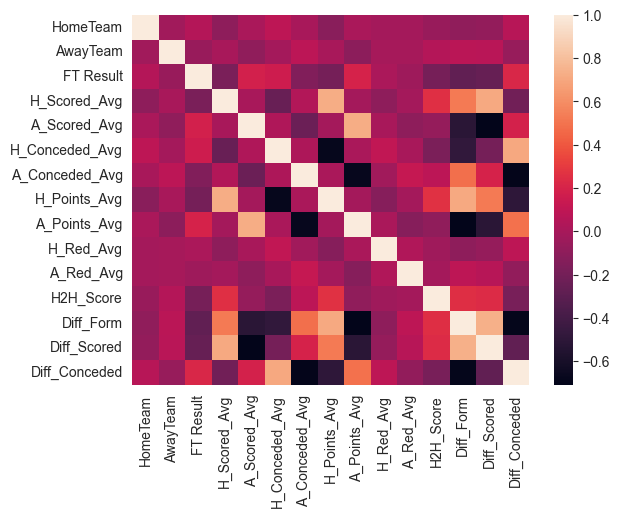

In [27]:
sns.heatmap(df.corr(numeric_only=True))


Deocamdata se observa rezultate intre :
- goluri si puncte
- forma(diferenta de forma) si puncte
- H2H depinde putin de golurile inscrise de echipele de acasa

**Nota** : diferenta de forma este media de puncte(forma) echipei de acasa - cea din deplasare.

Mai departe vom face grafice cu noile rezultate calculate sa vedem cum este distributia lor in functie de rezultatul final.

### Grafice cu media golurilor in functie de rezultatul final.

Ce se poate observa din informatiile datelor de pana acum:
- FT Result e aproape de 1(Draw) si de 0(castiga echipa gazda), asta si pentru ca media golurilor inscrise si primite sunt asemanatoare, asemenea si pentru puncte.
Deci multe meciuri, o mare majoritate, au rezultatul final in favoarea egalului sau a echipei de acasa.
- media cartonaselor rosii nu ne ajuta ca e aproape 0
- media golurilor inscrise acasa

In [28]:
df.describe()

,HomeTeam,AwayTeam,FT Result,H_Scored_Avg,A_Scored_Avg,H_Conceded_Avg,A_Conceded_Avg,H_Points_Avg,A_Points_Avg,H_Red_Avg,A_Red_Avg,H2H_Score,Diff_Form,Diff_Scored,Diff_Conceded
count,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000,9049.000000
mean,24.653000,24.702509,0.837330,1.357807,1.372041,1.367488,1.344966,1.369654,1.396044,0.074329,0.074019,1.243894,-0.026390,-0.014234,0.022522
std,14.431017,14.409613,0.852296,0.652474,0.645210,0.617473,0.612978,0.684296,0.679377,0.122874,0.122665,1.387257,0.968825,0.915705,0.859699
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.000000,-3.800000,-4.000000
25%,14.000000,14.000000,0.000000,0.800000,1.000000,1.000000,1.000000,0.800000,0.800000,0.000000,0.000000,0.000000,-0.600000,-0.600000,-0.600000
50%,26.000000,26.000000,1.000000,1.200000,1.200000,1.400000,1.200000,1.400000,1.400000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,38.000000,38.000000,2.000000,1.800000,1.800000,1.800000,1.800000,1.800000,1.800000,0.200000,0.200000,2.000000,0.600000,0.600000,0.600000
max,47.000000,47.000000,2.000000,5.800000,4.800000,4.200000,4.600000,3.000000,3.000000,0.800000,0.800000,5.000000,3.000000,5.200000,3.400000


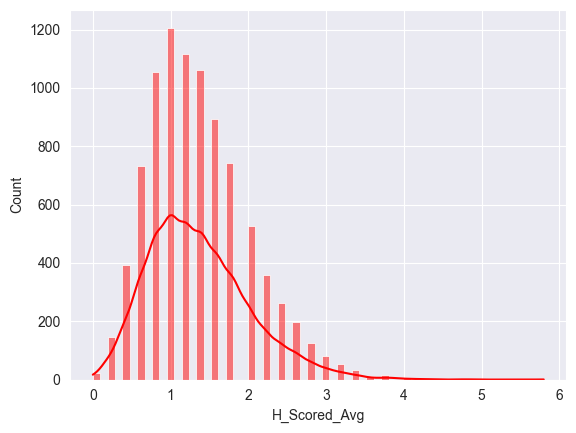

In [29]:
sns.histplot(data=df, x='H_Scored_Avg',kde=True, color='red')
plt.show()

In graficul de mai jos putem observa ca media este aproape asemanatoare la inscrierea golurile de ambele tipuri de echipe. Totusi, echipa din deplasare ar niste anomalii mult mai apropiate de zona acceptabila, fata de echipele de acasa.

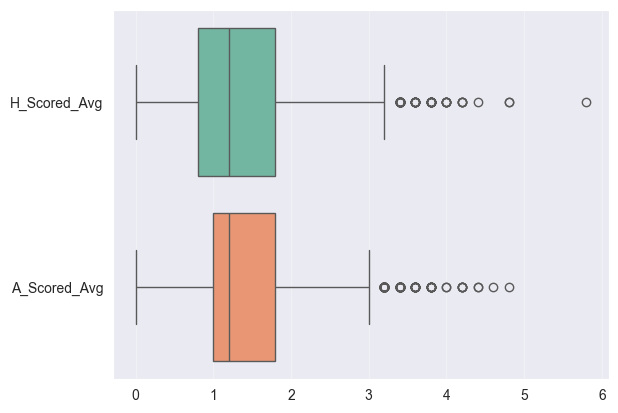

In [30]:
sns.boxplot(data=df[['H_Scored_Avg', 'A_Scored_Avg']], orient='h', palette='Set2')
plt.grid(axis='x', alpha=0.3)
plt.show()

In graficul de mai jos ne sunt explicate urmatoarele:
- majoritatea echipelor de acasa  reusesc sa aiba 0,1 sau maxim 2 victorii in ultimele 5 meciuri cu cealalta echipa, media fiind la 1.
- este prezentata si diferenta de forma. Exista echipe care au avut o forma exceptionala sau mai putin buna, in afara intervalului 'normal', cu 3 victorii sau infrangeri.Media este la 0, deoarece cele mai multe echipe au forma doar cu o victorie in plus sau in minus fata de alta, deci rezulta ca meciurile sunt destul de echilibrate.

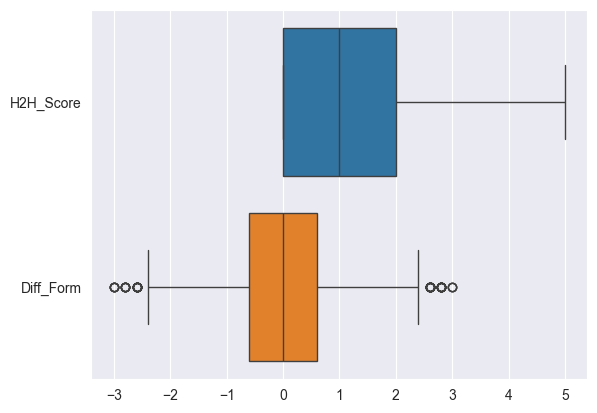

In [31]:
sns.boxplot(data=df[['H2H_Score','Diff_Form']], orient='h')
plt.show()

Mai departe, dorim sa vedem distributia valorilor in cazul unor atribute, cum ar fi:
- diferenta de goluri primite si date, forma
- media punctelor pentru fiecare echipa (acestea descriu si H2H)

<Axes: ylabel='Density'>

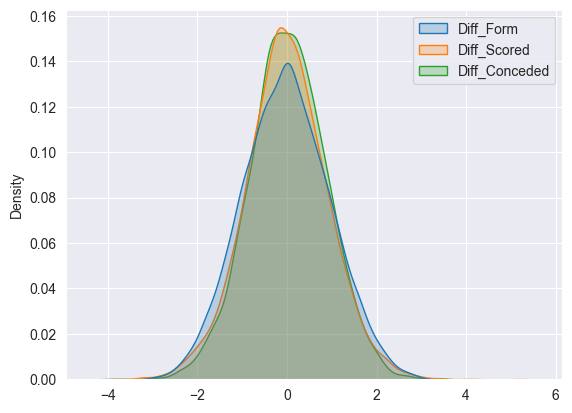

In [32]:
sns.kdeplot(data=df[['Diff_Form', 'Diff_Scored', 'Diff_Conceded']],fill=True)

- in graficul de mai sus, toate cele 3 sunt destul de asemanatoare, diferenta de forma are deviatia standart putin mai mare fata de celelalte.

### In urmatoarea parte dorim sa vede numeric, cat de strans sunt legate datele, prin coeficienti:

Cea mai puternica legatura cu rezultatul o are diferenta golurilor primite
- mai este si away avarage points

In [33]:
df.corr(numeric_only=True)

,HomeTeam,AwayTeam,FT Result,H_Scored_Avg,A_Scored_Avg,H_Conceded_Avg,A_Conceded_Avg,H_Points_Avg,A_Points_Avg,H_Red_Avg,A_Red_Avg,H2H_Score,Diff_Form,Diff_Scored,Diff_Conceded
HomeTeam,1.000000,-0.027256,0.052012,-0.097277,0.011889,0.090225,0.004533,-0.117078,0.011528,-0.007418,-0.010575,-0.059183,-0.090777,-0.077691,0.061571
AwayTeam,-0.027256,1.000000,-0.060717,0.002032,-0.093188,-0.007636,0.081020,0.003875,-0.104959,-0.006936,-0.002135,0.051267,0.076338,0.067108,-0.063253
FT Result,0.052012,-0.060717,1.000000,-0.180282,0.184872,0.154387,-0.148552,-0.200657,0.195374,0.018587,-0.035989,-0.193307,-0.278731,-0.258719,0.216807
H_Scored_Avg,-0.097277,0.002032,-0.180282,1.000000,0.004160,-0.248257,0.041668,0.725357,-0.011945,-0.095922,-0.013670,0.257091,0.520707,0.709606,-0.208019
A_Scored_Avg,0.011889,-0.093188,0.184872,0.004160,1.000000,0.027446,-0.235017,-0.012606,0.722370,0.002070,-0.099641,-0.072962,-0.515457,-0.701641,0.187283
H_Conceded_Avg,0.090225,-0.007636,0.154387,-0.248257,0.027446,1.000000,0.023690,-0.682549,0.006048,0.101077,0.001016,-0.169028,-0.486336,-0.196231,0.701352
A_Conceded_Avg,0.004533,0.081020,-0.148552,0.041668,-0.235017,0.023690,1.000000,0.007696,-0.676482,-0.023044,0.119857,0.085502,0.479811,0.195284,-0.696000
H_Points_Avg,-0.117078,0.003875,-0.200657,0.725357,-0.012606,-0.682549,0.007696,1.000000,-0.009473,-0.129643,-0.009157,0.263397,0.712958,0.525725,-0.495724
A_Points_Avg,0.011528,-0.104959,0.195374,-0.011945,0.722370,0.006048,-0.676482,-0.009473,1.000000,0.011255,-0.133829,-0.090234,-0.707929,-0.517497,0.486686
H_Red_Avg,-0.007418,-0.006936,0.018587,-0.095922,0.002070,0.101077,-0.023044,-0.129643,0.011255,1.000000,0.033545,-0.033874,-0.099461,-0.069807,0.089029


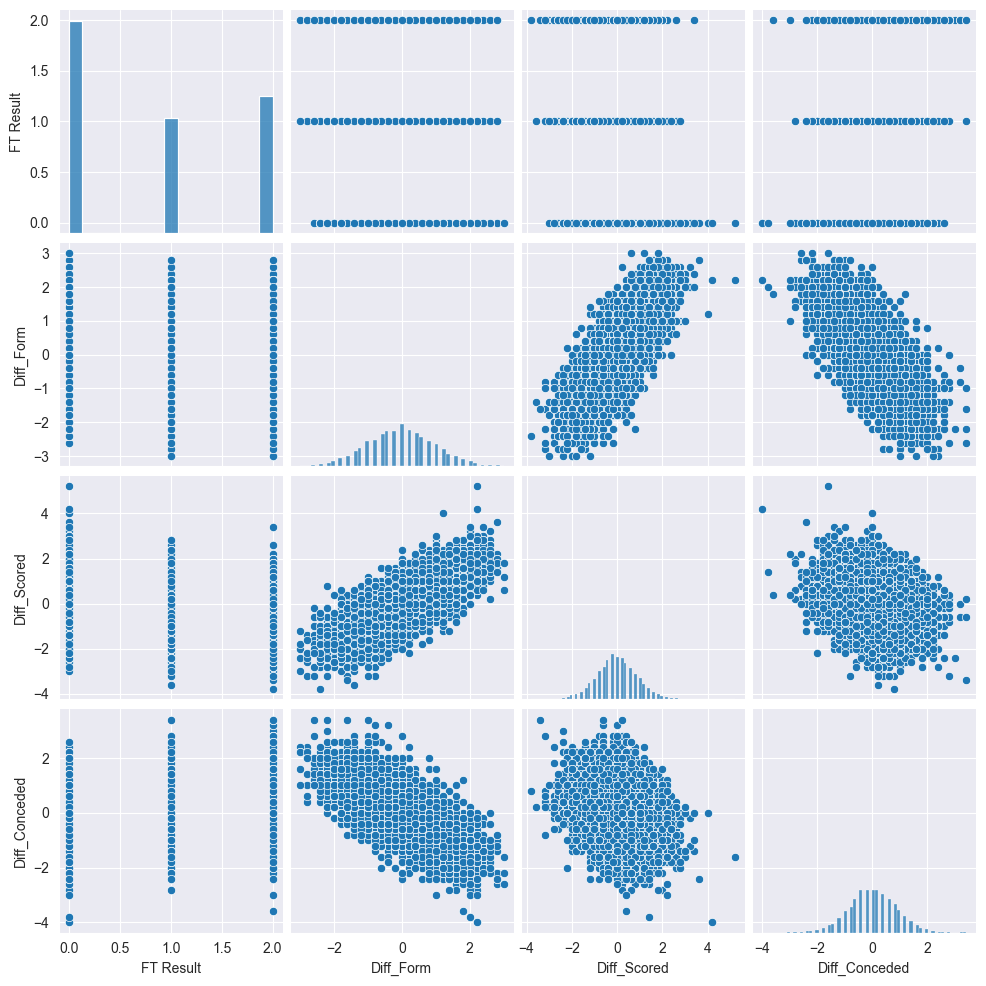

In [34]:
sns.pairplot(df[['FT Result', 'Diff_Form', 'Diff_Scored', 'Diff_Conceded']])

In graficele de mai sus, se observa o relatie de linearitate intre cele mai influente statistici asupra rezultatului final.
Aceasta proprietate apare intre :
- diferenta de forma cu diferenta de goluri inscrise si primite. Forma creste, diferenta de goluri primite scade (pentru gazda), daca forma creste, nr. de goluri inscrise creste.
DECI REZULTA URMATOARELE : forma direct proportional cu goluri inscrise si invers proportional cu goluri primite.

# Etapa de analiza a algoritmilor de clasificare
Un urmatoarea parte a notebook-ului se vor rula pe rand fiecare algoritm de clasificare din cerita, iar pe parcurs, la fiecare se va face analiza pe precizie,acuratete, recall, f1_score, dar si se va trasa si explica curba de invatare
In plus, se vor analiza rezultatele cu biblioteca ***SHAP*** si se vor ajusta hiperparametrii pentru a ajunge la rezultate mai bune, insa vor avea grija la overfitting.

## 1. Naïve Bayes
Scurta descriere: Se foloseste formula lui Bayes intr-o retea de tip bayes, unde exista mai multe noduri care sunt dependente intre ele.
Una dintre cele mai bune solutii este dupa formula lui Gauss, unde se urmaresste acea distributie sub forma unui clopot, avand formula :
$$P(x_i | y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma_y^2}\right)$$

- iar formula lui Bayes este : $$P(H | E) = \frac{P(E | H) \cdot P(H)}{P(E)}$$

**Nota**: In cazul nostru, vom folosi modelul gaussian, deoarece lucram pe date de tip numere.
- mai exista si multinomial care este pentru cuvinte(frecventa lor) sau Bernoulli care lucreaza doar cu valori binare.

*Hiperparamterii*:
- var_smoothing : pt a netezi curba, pentru stabilitatea calculelor - valoarea default = 1e-9.
- priors : influenteaza probabilitatile ( nu il folosim )

### 1.1 Naive Bayes cu parametrii default

In [35]:
from sklearn.preprocessing import StandardScaler

y = df['FT Result']
X = df.drop('FT Result',axis=1)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

              precision    recall  f1-score   support

           0       0.57      0.69      0.62      1006
           1       0.29      0.06      0.10       558
           2       0.44      0.59      0.50       699

    accuracy                           0.50      2263
   macro avg       0.43      0.45      0.41      2263
weighted avg       0.46      0.50      0.46      2263



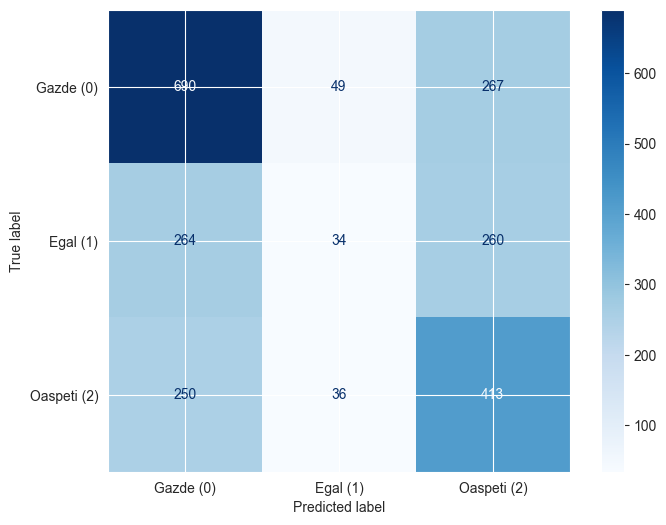

Total Accuracy: 0.50
Total precision : 0.46
Total Recall : 0.50
Total f1-score : 0.46
Total roc_auc : 0.64


In [36]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, confusion_matrix,classification_report, ConfusionMatrixDisplay

naive_ml = GaussianNB()

naive_ml.fit(X_train_scaled, y_train)
y_pred_Bayes =naive_ml.predict(X_test_scaled)
y_probs_Bayes = naive_ml.predict_proba(X_test_scaled)
print(classification_report(y_true=y_test, y_pred = y_pred_Bayes))

acc_bayes = accuracy_score(y_test, y_pred_Bayes)
prec_bayes = precision_score(y_test, y_pred_Bayes, average='weighted')
rec_bayes = recall_score(y_test, y_pred_Bayes, average='weighted')
f1_bayes = f1_score(y_test, y_pred_Bayes, average='weighted')
roc_auc_bayes = roc_auc_score(y_test, y_probs_Bayes, multi_class='ovr', average='weighted')

cm_bayes = confusion_matrix(y_test, y_pred_Bayes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bayes, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.show()
print(f"Total Accuracy: {acc_bayes:.2f}")
print(f"Total precision : {prec_bayes:.2f}")
print(f"Total Recall : {rec_bayes:.2f}")
print(f"Total f1-score : {f1_bayes:.2f}")
print(f"Total roc_auc : {roc_auc_bayes:.2f}")


#### Ce putem observa in datele prezise de Naive Bayes?
- Acuratetea este de 50%, adica avem sansa de 50% sa alegem rezultatul corect ( fata de 33% in cazul in care nu cunoastem).
- Precizia, recall si f1-score au rezultate foarte bune in cazul in care este castigatoare echipa gazda, dar si cea din deplasare are rezultate bunicele.
- Din acel recall de 0.06 de la rezultatul de egalitate rezulta faptul ca modelul nostru foarte rar alege rezultatul final ca fiind egalitate.
- Rezultatele finale de tip weighted reprezinta media ponderata pe toate cele 3 cazuri
- Din matricea de confuzie putem observa ca cele mai multe prezice victoriile gazdelor, apoi a oaspetilor
- Masurarea auc_roc, fiind folosita la clasificare binara, este folosit parametrul *ovr*(one versus rest), care face tot o binarizare, ce nu ne intereseaza pune in aceeasi clasa.


## 2. Logistic Regression
Acest algoritm de ML prezice probabilitatea pentru un tip, in cazul nostru probabilitatea daca meciul se va termina H, D, A. Din punct de vedere matematic, incearca sa separa planul in 2 parti, dupa functia sigmoid:
$$s(x) = \frac{1}{1 + e^{-x}}$$
- aceasta functie limiteaza valoriile intre 0 si 1, deoarece limita din infinit tinde la 1 aceasta functie iar din -infinit la 0.
- in functia de mai sus, x reprezinta combinatia liniara dintre toate variabilele si ponderile pe care le invata pe parcurs.
- Daca s(x) > 0.5 atunci este foarte probabil ca acest eveniment sa se intample, altfel nu.

### 2.1 Logisitc Regression cu parametrii default

              precision    recall  f1-score   support

           0       0.51      0.83      0.63      1006
           1       0.00      0.00      0.00       558
           2       0.47      0.42      0.44       699

    accuracy                           0.50      2263
   macro avg       0.33      0.42      0.36      2263
weighted avg       0.37      0.50      0.42      2263



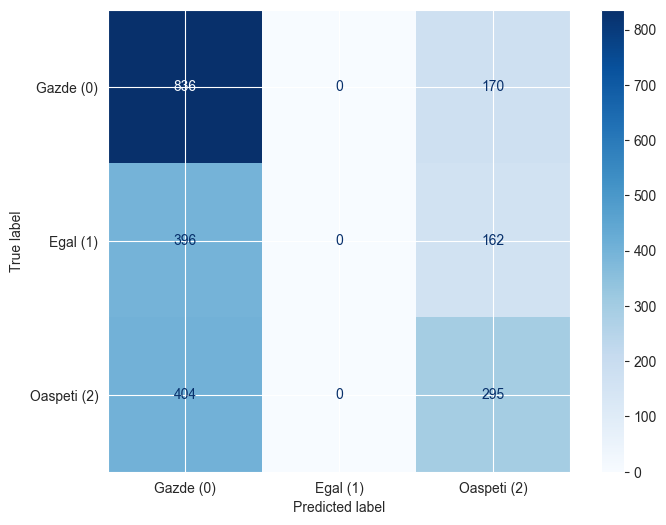

Total Accuracy: 0.50
Total precision : 0.37
Total Recall : 0.50
Total f1-score : 0.42
Total auc_roc : 0.64


In [37]:
from sklearn.linear_model import LogisticRegression
import warnings
from sklearn.exceptions import UndefinedMetricWarning

log_reg_ml = LogisticRegression(random_state=10)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
log_reg_ml.fit(X_train_scaled,y_train)
y_pred_logistic = log_reg_ml.predict(X_test_scaled)

print(classification_report(y_true=y_test, y_pred = y_pred_logistic))
acc_logistic = accuracy_score(y_test,y_pred_logistic)
prec_logistic = precision_score(y_test,y_pred_logistic, average='weighted')
f1_logistic = f1_score(y_test,y_pred_logistic, average='weighted')
rec_logistic = recall_score(y_test, y_pred_logistic, average='weighted')
y_probs_logistic = log_reg_ml.predict_proba(X_test_scaled)
auc_roc_logistic = roc_auc_score(y_test,y_probs_logistic, multi_class='ovr', average='weighted')

cm_logistic = confusion_matrix(y_test, y_pred_logistic)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistic, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.show()

print(f"Total Accuracy: {acc_logistic:.2f}")
print(f"Total precision : {prec_logistic:.2f}")
print(f"Total Recall : {rec_logistic:.2f}")
print(f"Total f1-score : {f1_logistic:.2f}")
print(f"Total auc_roc : {auc_roc_logistic:.2f}")

#### Ce putem observa in datele prezise de Logistic Regression?
- Problema majora a acestui model este faptul ca nu vede niciun rezultat ca egal, doar pe victoria gazdelor sau a oaspetilor.
- Auc_roc ramane asemanator, deci aproximatic la fel separa cazurile pozitive de cele negative.
- O mica imbunatatire apare in clasa gazdelor, unde recall si f1-score cresc putin.

### 3.Decision Tree
Acest model de ML creeaza o forma arborestenta, unde primeste ca input datele noastre, matricea X si in functie de niste conditii, la fiecare nod, merge pe ramura yes sau pe ramura no, pana la frunza.
Ca hiperparametru vom seta noi adancimea maxima.
In plus, modelul urmareste ca deciziile sa fie cat mai semnificative, importante, adica sa clasifice cat mai bine, dar si cat mai repede.

### 3.1 Decision Tree cu parametrii default

              precision    recall  f1-score   support

           0       0.51      0.50      0.50      1006
           1       0.26      0.26      0.26       558
           2       0.39      0.38      0.38       699

    accuracy                           0.41      2263
   macro avg       0.38      0.38      0.38      2263
weighted avg       0.41      0.41      0.41      2263



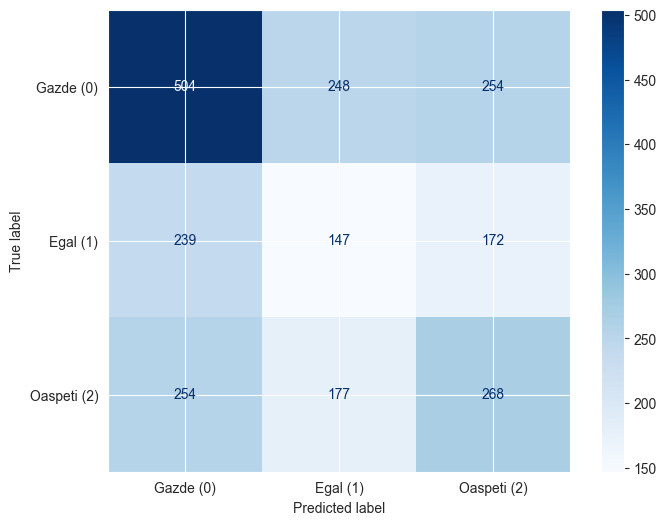

Total Accuracy: 0.41
Total precision : 0.41
Total Recall : 0.41
Total f1-score : 0.41
Total auc_roc : 0.54


In [38]:
from sklearn.tree import DecisionTreeClassifier

dec_tree_ML= DecisionTreeClassifier(random_state=10)

dec_tree_ML.fit(X_train_scaled,y_train)
y_pred_tree = dec_tree_ML.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred = y_pred_tree))

acc_tree = accuracy_score(y_test,y_pred_tree)
prec_tree = precision_score(y_test,y_pred_tree, average='weighted')
f1_tree = f1_score(y_test,y_pred_tree, average='weighted')
rec_tree = recall_score(y_test, y_pred_tree, average='weighted')
y_probs_tree = dec_tree_ML.predict_proba(X_test_scaled)
auc_roc_tree = roc_auc_score(y_test,y_probs_tree, multi_class='ovr', average='weighted')

cm_tree = confusion_matrix(y_test, y_pred_tree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.show()

print(f"Total Accuracy: {acc_tree:.2f}")
print(f"Total precision : {prec_tree:.2f}")
print(f"Total Recall : {rec_tree:.2f}")
print(f"Total f1-score : {f1_tree:.2f}")
print(f"Total auc_roc : {auc_roc_tree:.2f}")

#### Ce putem observa in datele prezise de Decision Tree?
- metricile sunt putin mai slabe sau egale.
- acum vede si mizeaza pe rezultatele de egal, dar cu costul reducerii celorlalte metrici, inclusiv auc_roc, rezultand faptul ca nu mai difera asa bine intre pozitiv si negativ.


## 4. Random Forest
In acest model de ML, exista mai multi Decision Trees, fiecare are partea sa de date si clasifica in functie de datele pe care le primeste.
Fiecare dintre arbori face o predictie, iar la final toate predictiile se combina si rezulta rezultatul final.
Un punct forte este faptul ca arata ce data din tabel(coloana) are o influenta mare.

### 4.1 Random Forest cu parametrii default

              precision    recall  f1-score   support

           0       0.52      0.76      0.61      1006
           1       0.25      0.08      0.12       558
           2       0.46      0.40      0.43       699

    accuracy                           0.48      2263
   macro avg       0.41      0.41      0.39      2263
weighted avg       0.43      0.48      0.44      2263



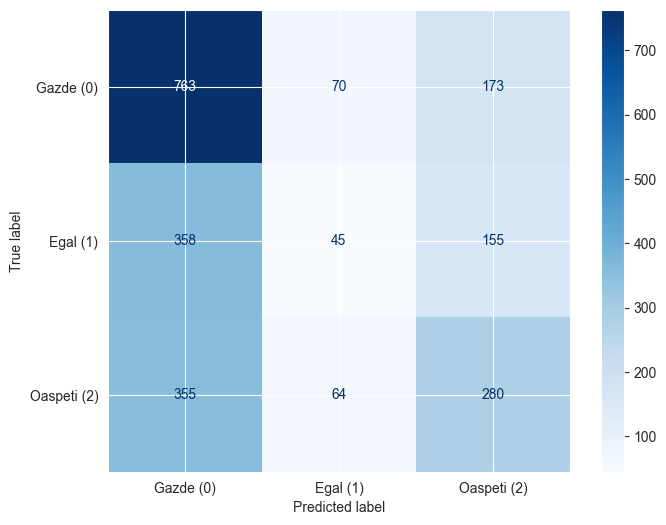

Total Accuracy: 0.48
Total precision : 0.43
Total Recall : 0.48
Total f1-score : 0.44
Total auc_roc : 0.63


In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_Ml =RandomForestClassifier(random_state=10)
rf_Ml.fit(X_train_scaled, y_train)
y_pred_rf =rf_Ml.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred = y_pred_rf))

acc_rf = accuracy_score(y_test,y_pred_rf)
prec_rf = precision_score(y_test,y_pred_rf, average='weighted')
f1_rf = f1_score(y_test,y_pred_rf, average='weighted')
rec_rf= recall_score(y_test, y_pred_rf, average='weighted')
y_probs_rf = rf_Ml.predict_proba(X_test_scaled)
auc_roc_rf = roc_auc_score(y_test,y_probs_rf, multi_class='ovr', average='weighted')

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.show()

print(f"Total Accuracy: {acc_rf:.2f}")
print(f"Total precision : {prec_rf:.2f}")
print(f"Total Recall : {rec_rf:.2f}")
print(f"Total f1-score : {f1_rf:.2f}")
print(f"Total auc_roc : {auc_roc_rf:.2f}")

#### Ce putem observa in datele prezise de Random Forest?
- o imbunatatie per total fata de decision tree, oarecum normala, deoarece sunt mai multi arbori.
- ca performante se apropie de naive bayes si logistic regression, cu mentiunea ca vede egalurile putin mai mult fata de modele mentionate anterior.
- un plus mare fata de logistic regression sunt score-urile de la 'egal'

## 5. Support vector machine
SVM incearca clasificarea prin impartiea spatiului intreg de stari in subspatii, cu ajutorul unor vectori suport.De fapt, se incearca maximizarea marginii, adică a distanței euclidiene dintre hiperplanul de decizie și cele mai apropiate puncte din fiecare clasă, numite vectori suport.
Exista 2 metode pentru clasificare :
- liniara, unde planele sunt impartite cu ajutorul unui vector
- kernel, unde se incearca adaptarea formei geometrice dupa distributia valorilor.


### 5.1 Support Vector Machine cu parametrii default


              precision    recall  f1-score   support

           0       0.51      0.85      0.64      1006
           1       1.00      0.00      0.01       558
           2       0.49      0.41      0.45       699

    accuracy                           0.51      2263
   macro avg       0.67      0.42      0.36      2263
weighted avg       0.63      0.51      0.42      2263



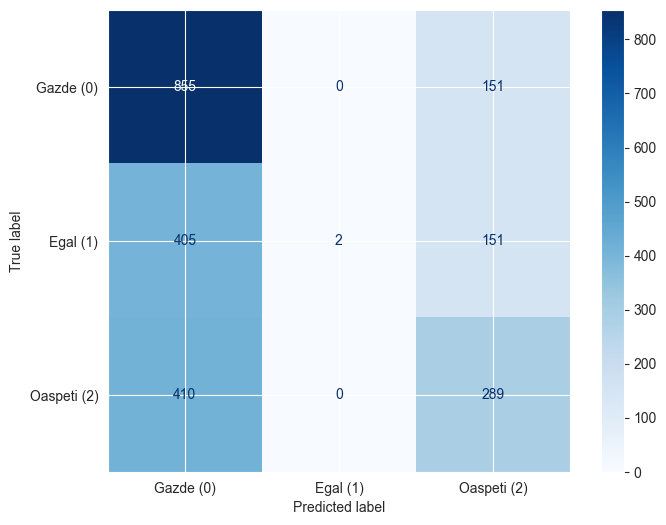

Total Accuracy: 0.51
Total precision : 0.63
Total Recall : 0.51
Total f1-score : 0.42
Total auc_roc : 0.61


In [40]:
from sklearn.svm import SVC

svm_ml = SVC(probability=True, random_state=10)

svm_ml.fit(X_train_scaled, y_train)
y_pred_svm =svm_ml.predict(X_test_scaled)
y_proba_svm = svm_ml.predict_proba(X_test_scaled)

print(classification_report(y_true=y_test, y_pred = y_pred_svm))

acc_svm = accuracy_score(y_test,y_pred_svm)
prec_svm = precision_score(y_test,y_pred_svm, average='weighted')
f1_svm = f1_score(y_test,y_pred_svm, average='weighted')
rec_svm= recall_score(y_test, y_pred_svm, average='weighted')
y_probs_svm = svm_ml.predict_proba(X_test_scaled)
auc_roc_svm = roc_auc_score(y_test,y_probs_svm, multi_class='ovr', average='weighted')

cm_svm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.show()

print(f"Total Accuracy: {acc_svm:.2f}")
print(f"Total precision : {prec_svm:.2f}")
print(f"Total Recall : {rec_svm:.2f}")
print(f"Total f1-score : {f1_svm:.2f}")
print(f"Total auc_roc : {auc_roc_svm:.2f}")

#### Ce putem observa in datele prezise de Support Vector Machine?
- Din nou, nu poate vedea rezultatul final ca fiind egal, precizia de 100% reprezinta o anomalie, deoarece spune din intamplare de 2 ori egal si fix atunci nimereste rezultatul.


## 6. K-Nearest Neighbors
K-Nearest Neighbors este un algoritm de clasificare ML, unde exista mai multe categorii de clase, iar input-ul sau valoarea care trebuie prezisa, ia valoarea clasei ce domina in vecinatatea sa.
Acest model se bazeaza pe urmatorii pasi:
- se calculeaza distanta fata de valoarea pe care dorim sa o clasificam si cele mai apropiate puncte.Distanta poate fi calculata in mai multe moduri, de exemplu: distanta euclidiana, manhattan, minkowski.
- se formeaza un cerc care cuntine *K* vecini (! nu neaparat toate punctele pentru care se calculeaza distanta trebuie sa faca parte din cerc)
- punctul K este clasificat drept clasa dominanta din interiorul cercului.

1. Distanta Euclidiana: $$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$
2. Distanta Manhattan: $$d(x, y) = \sum_{i=1}^{n} |x_i - y_i|$$
3. Distanta Minkowski: $$d(x, y) = \left( \sum_{i=1}^{n} |x_i - y_i|^p \right)^{\frac{1}{p}}$$


### 6.1 K-Nearest Neighbors cu parametrii default

              precision    recall  f1-score   support

           0       0.49      0.71      0.58      1006
           1       0.24      0.16      0.19       558
           2       0.43      0.25      0.32       699

    accuracy                           0.43      2263
   macro avg       0.39      0.38      0.36      2263
weighted avg       0.41      0.43      0.40      2263



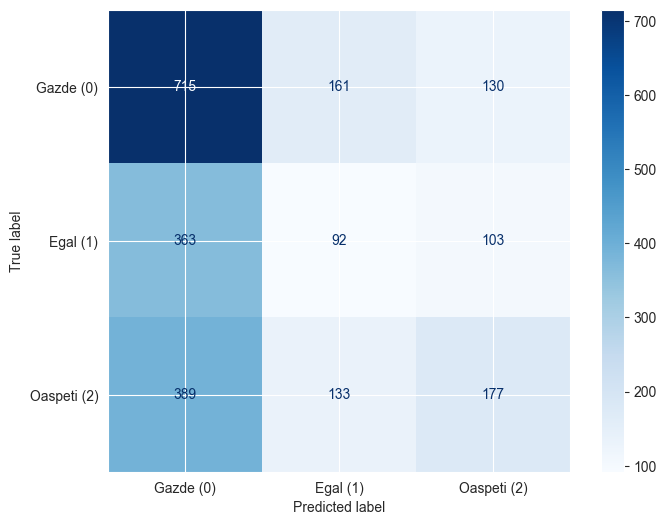

Total Accuracy: 0.43
Total precision : 0.41
Total Recall : 0.43
Total f1-score : 0.40
Total auc_roc : 0.57


In [41]:
from sklearn.neighbors import KNeighborsClassifier

knn_base = KNeighborsClassifier() # nu foloseste random state

knn_base.fit(X_train_scaled, y_train)
y_pred_knn = knn_base.predict(X_test_scaled)
y_proba_knn = knn_base.predict_proba(X_test_scaled)

print(classification_report(y_true=y_test, y_pred = y_pred_knn))

acc_knn = accuracy_score(y_test,y_pred_knn)
prec_knn = precision_score(y_test,y_pred_knn, average='weighted')
f1_knn = f1_score(y_test,y_pred_knn, average='weighted')
rec_knn = recall_score(y_test, y_pred_knn, average='weighted')
y_probs_knn = knn_base.predict_proba(X_test_scaled)
auc_roc_knn = roc_auc_score(y_test,y_probs_knn, multi_class='ovr', average='weighted')

cm_knn = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.show()

print(f"Total Accuracy: {acc_knn:.2f}")
print(f"Total precision : {prec_knn:.2f}")
print(f"Total Recall : {rec_knn:.2f}")
print(f"Total f1-score : {f1_knn:.2f}")
print(f"Total auc_roc : {auc_roc_knn:.2f}")


#### Ce putem observa in datele prezise de K-Nearest Neighbors?
- Rezultate overall sunt putin mai slabe, pierde pe partea de meciuri la oaspeti.
- Modelul vede la fel de bine clasele de clasificare
- Un lucru neasteptat este faptul ca vede mult mai bine decat orice alt algoritm in afara de decision tree pe rezultatul de egalitate


## 7. Xtreme Gradient Boost
Acest model de Machine Learning are la baza tot modelul _Decision Tree_ , insa complet diferit de _Random Forest_.
Cu ce difera?
- Arborii nu lucreaza paralel, ci concurent.Fiecare arbore se antreneaza pe erorile celui anterior, iar in final se combina predictiile.
- Un avantaj este acela ca previne overfitting.
- Exista si o metoda de regularizare, ce are ca scop penalitatea complexitatii, dupa o formula matematica foarte complexa.

### 7.1 Xtreme Gradient Boost cu parametrii default

              precision    recall  f1-score   support

           0       0.53      0.69      0.60      1006
           1       0.24      0.13      0.17       558
           2       0.46      0.43      0.44       699

    accuracy                           0.47      2263
   macro avg       0.41      0.42      0.40      2263
weighted avg       0.44      0.47      0.44      2263



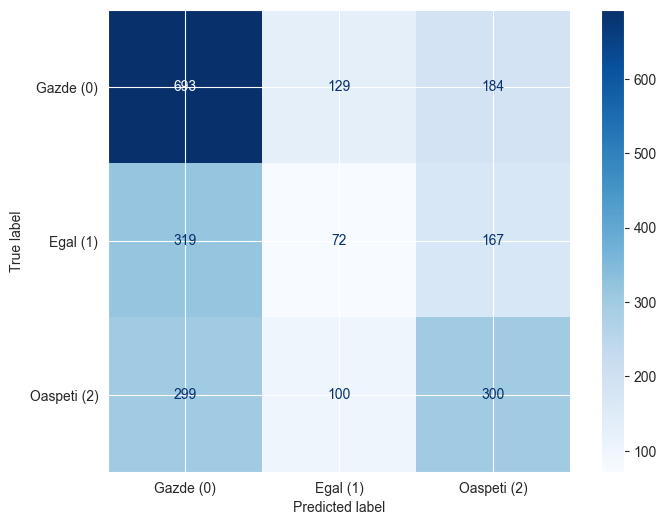

Total Accuracy: 0.47
Total precision : 0.44
Total Recall : 0.47
Total f1-score : 0.44
Total auc_roc : 0.63


In [42]:
from xgboost import XGBClassifier

xgb_base = XGBClassifier(random_state=10)
xgb_base.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_base.predict(X_test_scaled)
y_proba_xgb = xgb_base.predict_proba(X_test_scaled)
print(classification_report(y_true=y_test, y_pred = y_pred_xgb))

acc_xgb = accuracy_score(y_test,y_pred_xgb)
prec_xgb = precision_score(y_test,y_pred_xgb, average='weighted')
f1_xgb = f1_score(y_test,y_pred_xgb, average='weighted')
rec_xgb = recall_score(y_test, y_pred_xgb, average='weighted')
y_probs_xgb = xgb_base.predict_proba(X_test_scaled)
auc_roc_xgb = roc_auc_score(y_test,y_probs_xgb, multi_class='ovr', average='weighted')

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.show()

print(f"Total Accuracy: {acc_xgb:.2f}")
print(f"Total precision : {prec_xgb:.2f}")
print(f"Total Recall : {rec_xgb:.2f}")
print(f"Total f1-score : {f1_xgb:.2f}")
print(f"Total auc_roc : {auc_roc_xgb:.2f}")

#### Ce putem observa in datele prezise de Xtreme Gradient Boost?
- rezultate asemanatoare , putin mai bune
- putin mai avansat fata de modelul anterior, cel cu K vecini

## 8. Categorical Boost
Este un model din familia Gradient Boosting, optimizat pentru stabilitate și procesare rapida.
Cu ce se remarca?
- Date categoriale: Gestioneaza automat variabilele de tip text/eticheta, fara a necesita transformari manuale complexe.
- Arbori simetrici: Folosește Oblivious Trees (aceeasi conditie de split pe tot nivelul arborelui), ceea ce previne overfitting-ul.


              precision    recall  f1-score   support

           0       0.53      0.74      0.62      1006
           1       0.24      0.10      0.14       558
           2       0.50      0.44      0.47       699

    accuracy                           0.49      2263
   macro avg       0.42      0.43      0.41      2263
weighted avg       0.45      0.49      0.46      2263



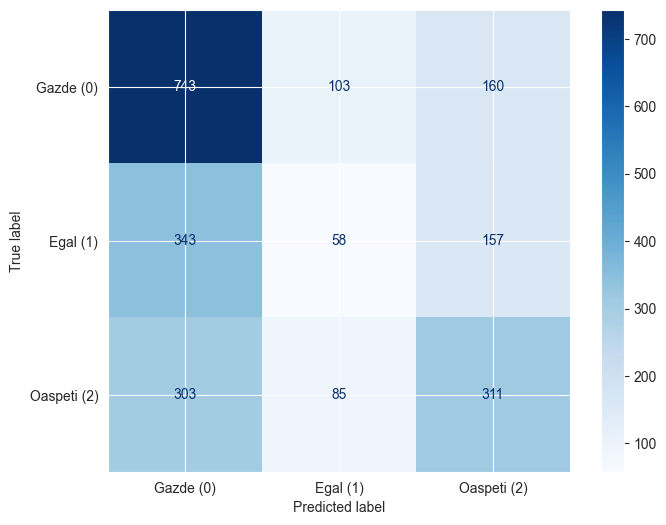

Total Accuracy: 0.49
Total precision : 0.45
Total Recall : 0.49
Total f1-score : 0.46
Total auc_roc : 0.63


In [43]:
from catboost import CatBoostClassifier

cat_base = CatBoostClassifier(verbose=0,random_state=10)
cat_base.fit(X_train_scaled, y_train)
y_pred_cat = cat_base.predict(X_test_scaled)
y_proba_cat = cat_base.predict_proba(X_test_scaled)
print(classification_report(y_true=y_test, y_pred = y_pred_cat))

acc_cat = accuracy_score(y_test,y_pred_cat)
prec_cat = precision_score(y_test,y_pred_cat, average='weighted')
f1_cat = f1_score(y_test,y_pred_cat, average='weighted')
rec_cat = recall_score(y_test, y_pred_cat, average='weighted')
y_probs_cat = cat_base.predict_proba(X_test_scaled)
auc_roc_cat = roc_auc_score(y_test,y_probs_cat, multi_class='ovr', average='weighted')

cm_cat = confusion_matrix(y_test, y_pred_cat)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cat, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.show()

print(f"Total Accuracy: {acc_cat:.2f}")
print(f"Total precision : {prec_cat:.2f}")
print(f"Total Recall : {rec_cat:.2f}")
print(f"Total f1-score : {f1_cat:.2f}")
print(f"Total auc_roc : {auc_roc_cat:.2f}")


#### Ce putem observa in datele prezise de Categorical Boost?
- printre cele mai echilibrate modele de Machine Learning
- problema comuna ar fi la egalitate


## 9. Explainable Boosting Machine
- Analizeaza fiecare trasatura separat: Modelul invata o funcție pentru fiecare coloana
- Rezultatul final este suma acestor analize.
- Exista si perechi de variabile care interactioneaza.

              precision    recall  f1-score   support

           0       0.53      0.85      0.65      1006
           1       0.67      0.00      0.01       558
           2       0.51      0.47      0.49       699

    accuracy                           0.52      2263
   macro avg       0.57      0.44      0.38      2263
weighted avg       0.56      0.52      0.44      2263



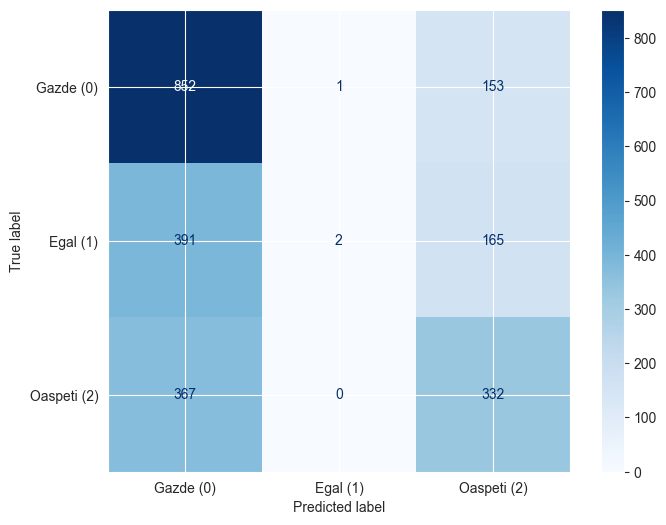

Total Accuracy: 0.52
Total precision : 0.56
Total Recall : 0.52
Total f1-score : 0.44
Total auc_roc : 0.66


In [44]:
from interpret.glassbox import ExplainableBoostingClassifier

warnings.filterwarnings("ignore", category=UserWarning)
ebm_ml = ExplainableBoostingClassifier(random_state=10)
ebm_ml.fit(X_train_scaled, y_train)
y_pred_ebm = ebm_ml.predict(X_test_scaled)
y_proba_ebm = ebm_ml.predict_proba(X_test_scaled)
print(classification_report(y_true=y_test, y_pred = y_pred_ebm))

acc_ebm = accuracy_score(y_test,y_pred_ebm)
prec_ebm = precision_score(y_test,y_pred_ebm, average='weighted')
f1_ebm = f1_score(y_test,y_pred_ebm, average='weighted')
rec_ebm = recall_score(y_test, y_pred_ebm, average='weighted')
y_probs_ebm = ebm_ml.predict_proba(X_test_scaled)
auc_roc_ebm = roc_auc_score(y_test,y_probs_ebm, multi_class='ovr', average='weighted')

cm_ebm = confusion_matrix(y_test, y_pred_ebm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ebm, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.show()

print(f"Total Accuracy: {acc_ebm:.2f}")
print(f"Total precision : {prec_ebm:.2f}")
print(f"Total Recall : {rec_ebm:.2f}")
print(f"Total f1-score : {f1_ebm:.2f}")
print(f"Total auc_roc : {auc_roc_ebm:.2f}")


#### Ce putem observa in datele prezise de Explainable Boosting Machine?
- nu vede absolut deloc rezultatele de egalitate
- daca le-ar vedea, ar putea fi printre cele mai bune.


### Cateva concluzii dupa modelele ML cu parametrii de baza:
- Cea mai buna acuratete din aceste modele de baza este de aproximativ 50%. As tinde sa spun in mod obiectiv faptul ca , in acest condex, de a prezice echipa castigatoare dintr-un meci de fotbal in Anglia este acceptabil, deoarece fara acest ajutor, probabilitatea ar fi de 33% pentru a 'nimeri'.
- O problema de la dataset ar fi ca sunt prea putine egaluri si poate din acest motiv nu sunt vazute asa bine.In plus, am incercat sa pun feature relevante, care influenteaza(poate cu adevarat) rezultatul, despre forma echipei.In ciuda faptului ca nu detin alte informatii relevante care au si influenta mai mare asupra rezultatului(daca e meci important, jucatori accidentati, etc), am incercat sa prelucrez datele detinute.

# Analiza comparativa

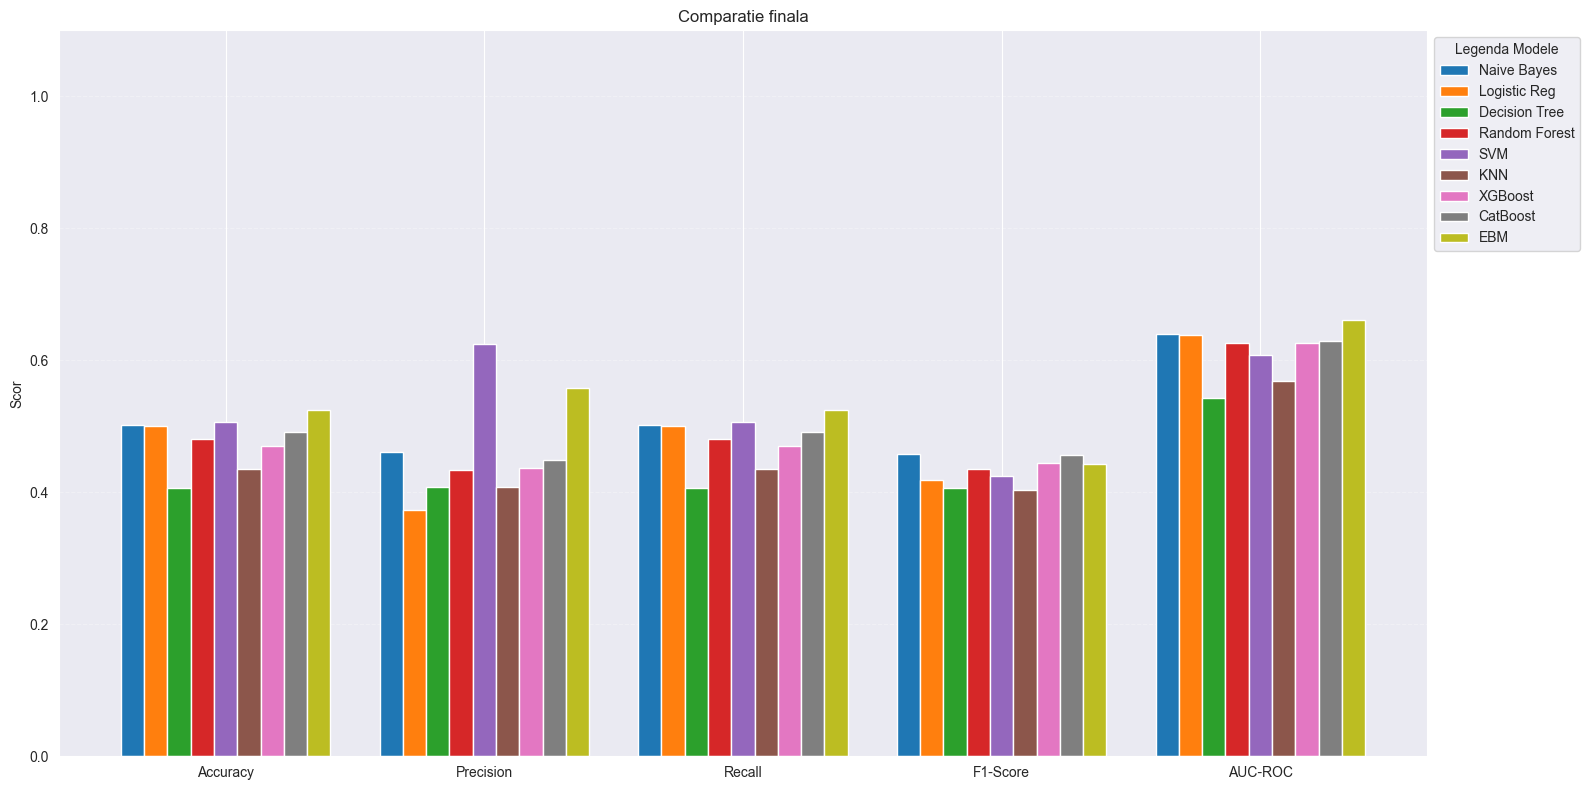

In [45]:
models_data = {
    'Naive Bayes':   [acc_bayes, prec_bayes, rec_bayes, f1_bayes, roc_auc_bayes],
    'Logistic Reg':  [acc_logistic, prec_logistic, rec_logistic, f1_logistic, auc_roc_logistic],
    'Decision Tree': [acc_tree, prec_tree, rec_tree, f1_tree, auc_roc_tree],
    'Random Forest': [acc_rf, prec_rf, rec_rf, f1_rf, auc_roc_rf],
    'SVM':           [acc_svm, prec_svm, rec_svm, f1_svm, auc_roc_svm],
    'KNN':           [acc_knn, prec_knn, rec_knn, f1_knn, auc_roc_knn],
    'XGBoost':       [acc_xgb, prec_xgb, rec_xgb, f1_xgb, auc_roc_xgb],
    'CatBoost':      [acc_cat, prec_cat, rec_cat, f1_cat, auc_roc_cat],
    'EBM':           [acc_ebm, prec_ebm, rec_ebm, f1_ebm, auc_roc_ebm]
}

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metric_names))
total_models = len(models_data)
width = 0.09

fig, ax = plt.subplots(figsize=(16, 8))
for i, (model_name, scores) in enumerate(models_data.items()):
    offset = (i - total_models/2) * width + width/2
    ax.bar(x + offset, scores, width, label=model_name)

ax.set_ylabel('Scor')
ax.set_title('Comparatie finala')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legenda Modele")
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#### Mai sus se poate observa grafic cu toate modelele comparate in functie de score-uri.
Ideea pentru a creea un top: Vom face o medie ponderata a score-urilor, fiecare avand o pondere care reprezinta importanta.Toate sunt importante, insa depinde de context importanta metricilor.(de ex auc_roc sa fie 0.1, dintr-un total de 1.0).
Recall si precision vor avea aceeasi pondere, deoarece si false positive si false negative sunt la fel de 'dureroase'/importante in acest context.

In [46]:
weights = {
    'Accuracy': 0.20,
    'Precision': 0.15,
    'Recall': 0.15,
    'F1-Score': 0.40,
    'AUC-ROC': 0.10
}

df_results = pd.DataFrame.from_dict(models_data, orient='index', columns=metric_names)
df_results['Weighted_Score'] = (
    df_results['Accuracy'] * weights['Accuracy'] +
    df_results['Precision'] * weights['Precision'] +
    df_results['Recall'] * weights['Recall'] +
    df_results['F1-Score'] * weights['F1-Score'] +
    df_results['AUC-ROC'] * weights['AUC-ROC']
)
top_5_final = df_results.sort_values(by='Weighted_Score', ascending=False).head(5)

print("Top 5 :")
display(top_5_final[['Weighted_Score', 'F1-Score', 'Accuracy', 'AUC-ROC','Recall','Precision']])

Top 5 :


,Weighted_Score,F1-Score,Accuracy,AUC-ROC,Recall,Precision
EBM,0.510437,0.443359,0.524083,0.660547,0.524083,0.557400
SVM,0.501539,0.424228,0.506407,0.608233,0.506407,0.625214
Naive Bayes,0.492244,0.458020,0.502430,0.640466,0.502430,0.460924
CatBoost,0.484758,0.456177,0.491383,0.629686,0.491383,0.448895
XGBoost,0.470546,0.444536,0.470614,0.625700,0.470614,0.436310


# Ajustarea hiperparametrilor si curbele de invatare a top 5 modele:
Pentru hiperparametrii voi folosi clasa GridSearchCV.O atentie sporita trebuie avuta la cazurile de overfitting si underfitting.
1. Underfitting = atunci cand un model este prea slab si nu acopera toate cazurile reale posibile
2. Overfitting = atunci cand un model este prea bun si invata inclusiv cazurile speciale, care sunt foarte greu de prezis.

__Curba de invatare__
- Vor exista 2 curbe, una de validare, alta antrenare.
- Cand cele 2 se aproprie foarte mult si foarte repede rezulta underfitting, iar cand este un spatiu prea mare rezulta overfitting.

Link-uri utile pentru hiperparametrii :
- https://interpret.ml/docs/hyperparameters.html
- https://scikit-learn.org/stable/modules/svm.html

Un parametru util la un ML ar fi **class_weight='balanced**, pentru ca modelul sa fie penalizat mai mult atunci cand greseste la o clasa care are un numar mai mic.

In plus, dorim sa gasim cel mai bun model in functie de *f1_weighted*, deoarece ignorarea rezultatului de egalitate trebuie sa fie penalizata. Totodata, am vazut ca precizia poate fi mare sau acuratetea, deoarece e ridicata de celelalte 2 clase.
In concluzie, consider ca f1 este cel mai bun scor de masurat, in plus, calculam f1 ponderat.


## 1. Explainable Boosting Machine

Fitting 3 folds for each of 144 candidates, totalling 432 fits
              precision    recall  f1-score   support

   Gazde (0)       0.53      0.84      0.65      1006
    Egal (1)       0.23      0.01      0.01       558
 Oaspeti (2)       0.51      0.47      0.49       699

    accuracy                           0.52      2263
   macro avg       0.42      0.44      0.38      2263
weighted avg       0.45      0.52      0.44      2263



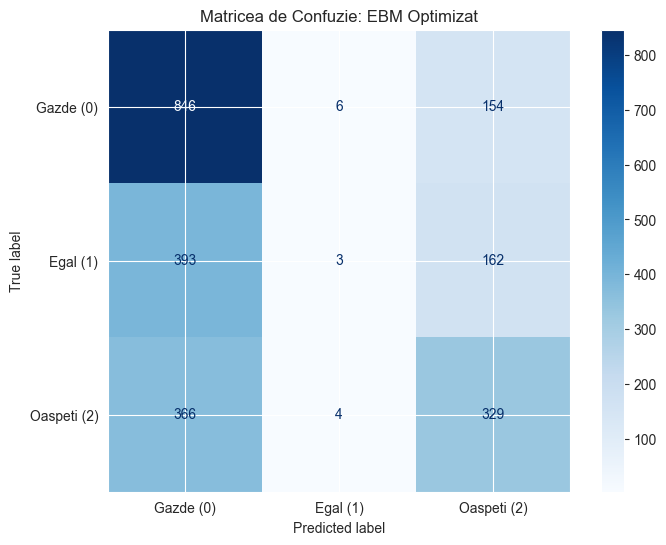

Total Accuracy: 0.52
Total precision : 0.45
Total Recall : 0.52
Total f1-score : 0.44
Total auc_roc : 0.66


In [47]:
ebm_grid = {
    'smoothing_rounds': [65, 70, 75, 80,],
    'learning_rate': [0.005, 0.01, 0.02],
    'interactions': [5,10],
    'outer_bags': [8, 12, 16],
    'min_samples_leaf': [2, 5],
    'max_bins': [256],
    'early_stopping_rounds': [50]
}

ebm_base = ExplainableBoostingClassifier(
    random_state=10,
    n_jobs=-1,
)

grid_search_ebm = GridSearchCV(
    estimator=ebm_base,
    param_grid=ebm_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search_ebm.fit(X_train_scaled, y_train)
best_ebm = grid_search_ebm.best_estimator_
y_pred_ebm_opt = best_ebm.predict(X_test_scaled)
y_probs_ebm_opt = best_ebm.predict_proba(X_test_scaled)
acc_ebm_opt = accuracy_score(y_test, y_pred_ebm_opt)
prec_ebm_opt = precision_score(y_test, y_pred_ebm_opt, average='weighted')
rec_ebm_opt = recall_score(y_test, y_pred_ebm_opt, average='weighted')
f1_ebm_opt = f1_score(y_test, y_pred_ebm_opt, average='weighted')
auc_roc_ebm_opt = roc_auc_score(y_test, y_probs_ebm_opt, multi_class='ovr', average='weighted')

print(classification_report(y_test, y_pred_ebm_opt, target_names=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)']))
cm_ebm_opt = confusion_matrix(y_test, y_pred_ebm_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ebm_opt, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
ax.set_title("Matricea de Confuzie: EBM Optimizat")
plt.show()

print(f"Total Accuracy: {acc_ebm_opt:.2f}")
print(f"Total precision : {prec_ebm_opt:.2f}")
print(f"Total Recall : {rec_ebm_opt:.2f}")
print(f"Total f1-score : {f1_ebm_opt:.2f}")
print(f"Total auc_roc : {auc_roc_ebm_opt:.2f}")

#### Modelul hiperparametrizat este la fel, chiar putin mai slab la precizie.
*Curba de invatare:*

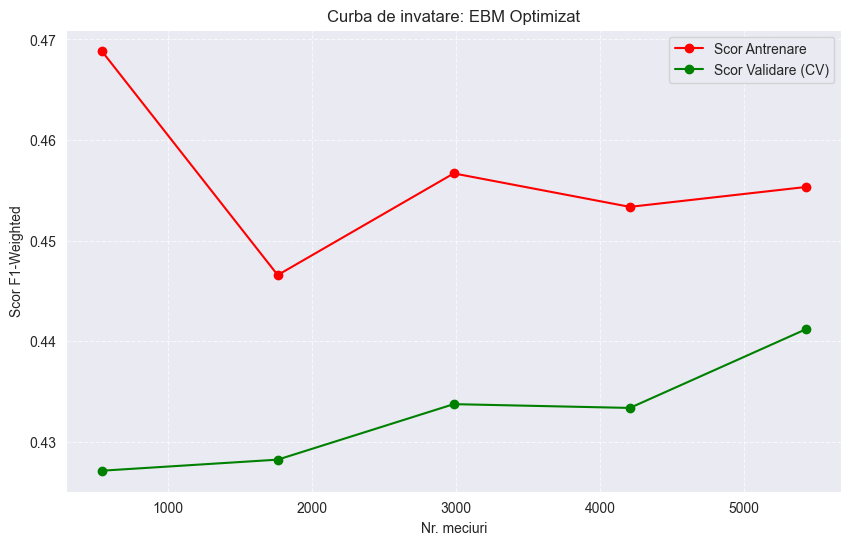

In [48]:
from Classes.Utils import plot_learning_curve

plot_learning_curve(best_ebm, X_train_scaled, y_train, "Curba de invatare: EBM Optimizat")

- Curba de invatare de mai sus ar putea fi la limita de underfitting, diferenta dintre antrenare si validare fiind in medie 0.03.
Consider ca acest lucru se intampla mai ales din cauza rezultatului de egalitate, deoarece nu existsa suficiente date pentru a defini o clasa de egalitate.
- Daca am creste numarul de meciuri, iar curba pentru validare ar converge spre cea de antrenare, atunci am fi in cazul de underfitting.
- In cazul nostru ,la inceput, la aproximativ 500 de meciuri exista cea mai mare diferenata intre antrenare si validare, dar nu poate fi considerat un caz de overfitting, deoarece diferenta e mult prea mica.

## 2. Support Vector Machine

Fitting 5 folds for each of 32 candidates, totalling 160 fits
              precision    recall  f1-score   support

   Gazde (0)       0.61      0.52      0.56      1006
    Egal (1)       0.25      0.27      0.26       558
 Oaspeti (2)       0.44      0.51      0.47       699

    accuracy                           0.45      2263
   macro avg       0.44      0.43      0.43      2263
weighted avg       0.47      0.45      0.46      2263



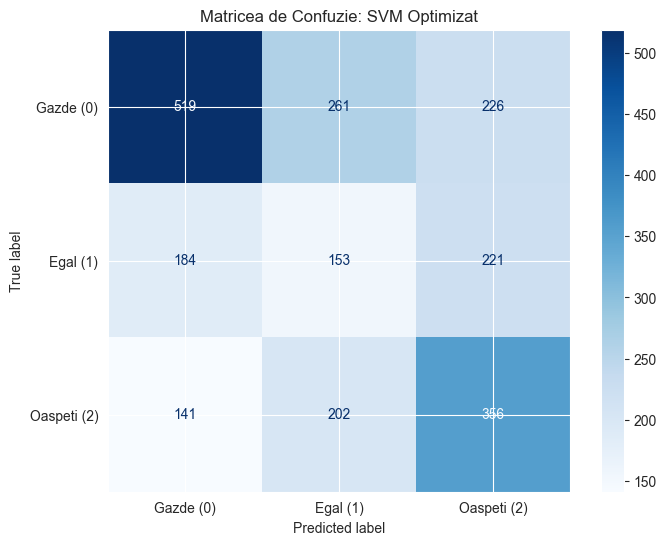

Total Accuracy: 0.45
Total precision : 0.47
Total Recall : 0.45
Total f1-score : 0.46
Total auc_roc : 0.64


In [49]:

svm_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto", 0.01, 0.1],
    'class_weight': ['balanced'],
    "decision_function_shape": ['ovr']
}

svm_base = SVC(
    random_state=10,
    probability=True,
)

grid_search_svm = GridSearchCV(
    estimator=svm_base,
    param_grid=svm_grid,
    n_jobs=-1,
    cv=5,
    scoring='f1_weighted',
    verbose=1
)

grid_search_svm.fit(X_train_scaled, y_train)
best_svm = grid_search_svm.best_estimator_
y_pred_svm_opt = best_svm.predict(X_test_scaled)
y_probs_svm_opt = best_svm.predict_proba(X_test_scaled)
acc_svm_opt = accuracy_score(y_test, y_pred_svm_opt)
prec_svm_opt = precision_score(y_test, y_pred_svm_opt, average='weighted')
rec_svm_opt = recall_score(y_test, y_pred_svm_opt, average='weighted')
f1_svm_opt = f1_score(y_test, y_pred_svm_opt, average='weighted')
auc_roc_svm_opt = roc_auc_score(y_test, y_probs_svm_opt, multi_class='ovr', average='weighted')

print(classification_report(y_test, y_pred_svm_opt, target_names=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)']))
cm_svm_opt = confusion_matrix(y_test, y_pred_svm_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm_opt, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
ax.set_title("Matricea de Confuzie: SVM Optimizat")
plt.show()

print(f"Total Accuracy: {acc_svm_opt:.2f}")
print(f"Total precision : {prec_svm_opt:.2f}")
print(f"Total Recall : {rec_svm_opt:.2f}")
print(f"Total f1-score : {f1_svm_opt:.2f}")
print(f"Total auc_roc : {auc_roc_svm_opt:.2f}")


Aceasta varianta de Support vector machine,optimizata, are la prima vede rezultate mai slabe, insa se datoreaza faptului ca  varianta default nu vedea rezultatele de egalitate.
Insa, acum putem observa faptul ca egalurile sunt obsesrvabile si prezice aproape o treime din ele corect, datorita faptului ca avem parapetrul _class_weight=balanced.
Optimizarea majora este pe partea rezultatului de egalitate si ofera niste estimari mult mai realiste.

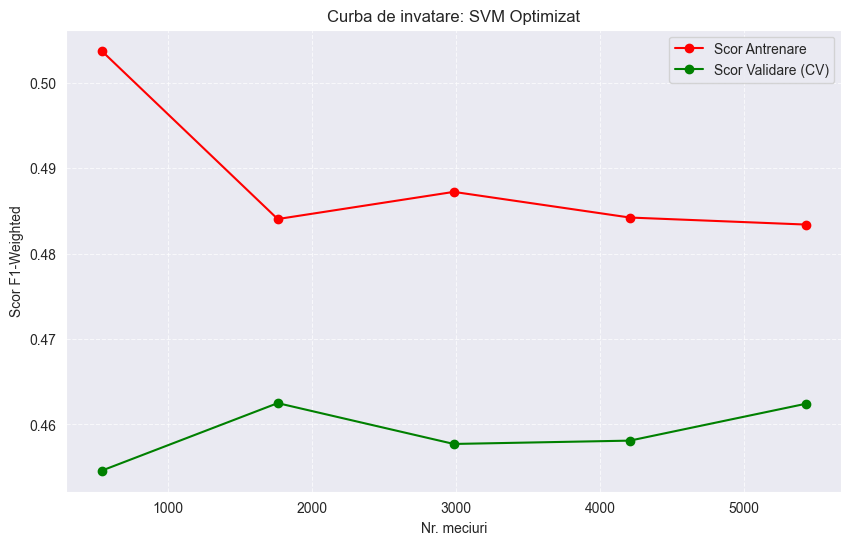

In [50]:
from Classes.Utils import plot_learning_curve

plot_learning_curve(best_svm, X_train_scaled, y_train, "Curba de invatare: SVM Optimizat")


In curba de invatare de mai sus este prezent un overfitting usor la inceput datorita faptului ca exista putine date. In acest conext, de ghicire a rezultatelor, am putut observa faptul ca greu se pot imbunatati rezultatele, iar 0.04 conteaza.
Argument in plus este reprezntat de faptul ca linia de antrenare este destul de inalta fata de validare.

## 3. Naive Bayes

Fitting 5 folds for each of 100 candidates, totalling 500 fits
              precision    recall  f1-score   support

   Gazde (0)       0.57      0.69      0.62      1006
    Egal (1)       0.29      0.06      0.10       558
 Oaspeti (2)       0.44      0.59      0.50       699

    accuracy                           0.50      2263
   macro avg       0.43      0.45      0.41      2263
weighted avg       0.46      0.50      0.46      2263



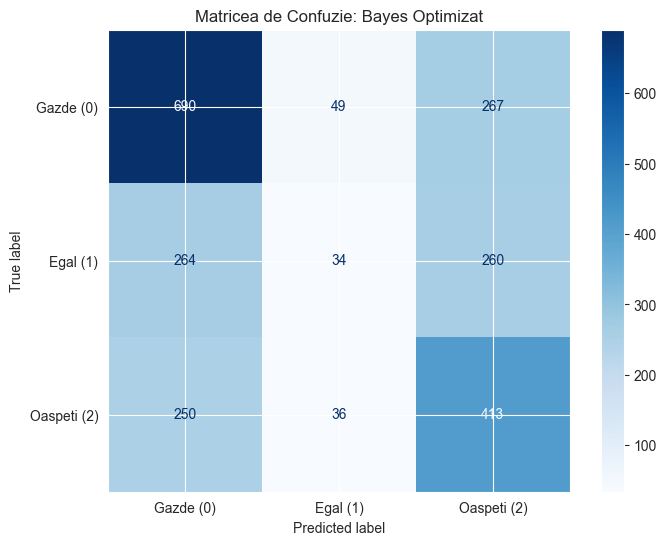

Total Accuracy: 0.50
Total precision : 0.46
Total Recall : 0.50
Total f1-score : 0.46
Total auc_roc : 0.64


In [51]:
nb_grid = {
    'var_smoothing': np.logspace(0, -9, num=100)
}
nb_base = GaussianNB()
grid_search_nb = GridSearchCV(
    estimator=nb_base,
    param_grid=nb_grid,
    cv=5,
    scoring='f1_weighted',
    verbose=1,
    n_jobs=-1
)

grid_search_nb.fit(X_train_scaled, y_train)
best_nb = grid_search_nb.best_estimator_
y_pred_nb_opt = best_nb.predict(X_test_scaled)
y_probs_nb_opt = best_nb.predict_proba(X_test_scaled)
acc_nb_opt = accuracy_score(y_test, y_pred_nb_opt)
prec_nb_opt = precision_score(y_test, y_pred_nb_opt, average='weighted')
rec_nb_opt = recall_score(y_test, y_pred_nb_opt, average='weighted')
f1_nb_opt = f1_score(y_test, y_pred_nb_opt, average='weighted')
auc_roc_nb_opt = roc_auc_score(y_test, y_probs_nb_opt, multi_class='ovr', average='weighted')

print(classification_report(y_test, y_pred_nb_opt, target_names=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)']))
cm_nb_opt = confusion_matrix(y_test, y_pred_nb_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb_opt, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
ax.set_title("Matricea de Confuzie: Bayes Optimizat")
plt.show()

print(f"Total Accuracy: {acc_nb_opt:.2f}")
print(f"Total precision : {prec_nb_opt:.2f}")
print(f"Total Recall : {rec_nb_opt:.2f}")
print(f"Total f1-score : {f1_nb_opt:.2f}")
print(f"Total auc_roc : {auc_roc_nb_opt:.2f}")

Rezultatele sunt asemanatoare cu modelul default, problema egalurilor persista, deoarece nu avem parametrul care ne ajuta sa ponderam clasele ( = balanced) .

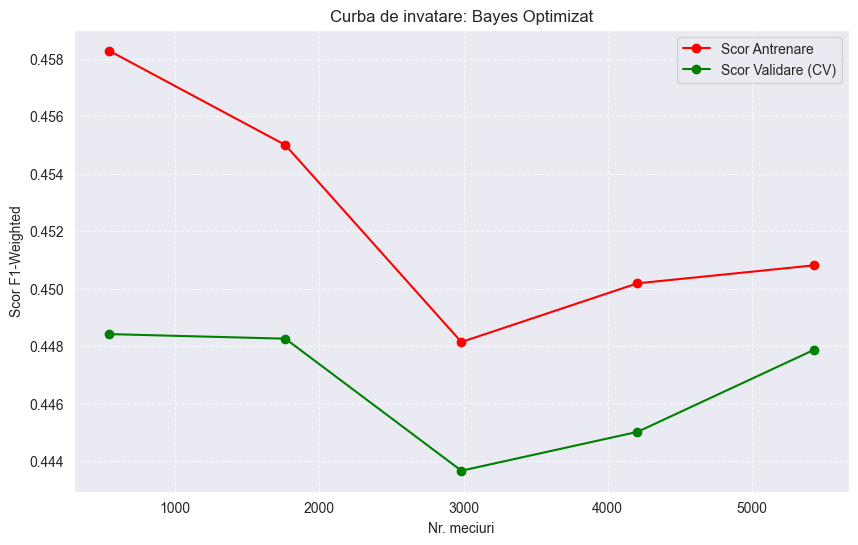

In [52]:
plot_learning_curve(best_nb, X_train_scaled, y_train, "Curba de invatare: Bayes Optimizat")


- Din graficul de mai sus rezulta o diferenta sutimi intre scorul de antrenare si validare, ceea ce inseamna, din pacate underfitting. Acest lucru se cauzeaza datorita faptului ca modelul Bayes este unul simplu, mult prea simplu pentru o clasificare complexa pe care o incerc.
- Spre deosebire de EBM și SVM, unde exista o usoara separare la volume mici de date, Bayes mentine aceasta diferenta minima indiferent de numarul de meciuri, semn ca modelul nu reuseste sa invete pattern-uri relevante din date.
- Simplitatea modelului rezulta si din timpul de executie care este aproape inexistent in comparatie cu celelalte modele.

## 4. Categorical Boost

Fitting 5 folds for each of 96 candidates, totalling 480 fits
0:	learn: 1.0977674	total: 3.46ms	remaining: 1.72s
1:	learn: 1.0969657	total: 6.73ms	remaining: 1.68s
2:	learn: 1.0961820	total: 10.1ms	remaining: 1.68s
3:	learn: 1.0953896	total: 13.2ms	remaining: 1.64s
4:	learn: 1.0946159	total: 15.9ms	remaining: 1.58s
5:	learn: 1.0938413	total: 18.7ms	remaining: 1.54s
6:	learn: 1.0930641	total: 21.2ms	remaining: 1.5s
7:	learn: 1.0923011	total: 23.7ms	remaining: 1.46s
8:	learn: 1.0915018	total: 26.3ms	remaining: 1.43s
9:	learn: 1.0906912	total: 28.9ms	remaining: 1.42s
10:	learn: 1.0900036	total: 31.3ms	remaining: 1.39s
11:	learn: 1.0892489	total: 33.8ms	remaining: 1.37s
12:	learn: 1.0886956	total: 36.4ms	remaining: 1.36s
13:	learn: 1.0880066	total: 39.3ms	remaining: 1.36s
14:	learn: 1.0873669	total: 41.7ms	remaining: 1.35s
15:	learn: 1.0867150	total: 44.2ms	remaining: 1.34s
16:	learn: 1.0861628	total: 46.6ms	remaining: 1.32s
17:	learn: 1.0854899	total: 49ms	remaining: 1.31s
18:	learn: 1.08

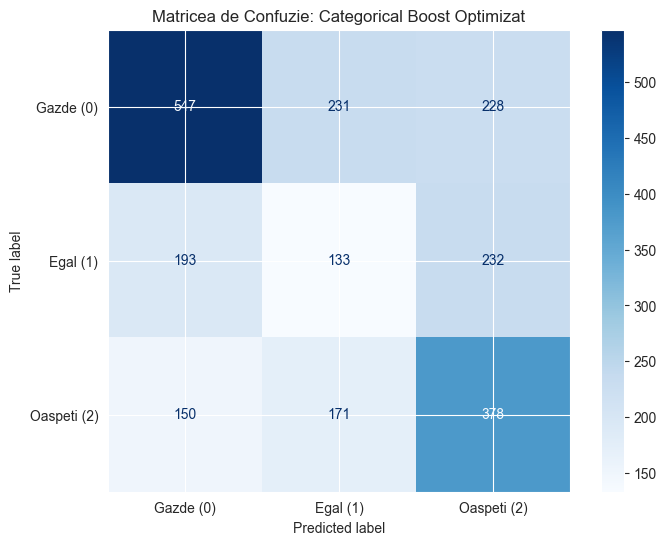

Total Accuracy: 0.47
Total precision : 0.47
Total Recall : 0.47
Total f1-score : 0.47
Total auc_roc : 0.65


In [53]:
cb_grid = {
    'iterations': [500, 1000],
    'depth': [4, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7],
    'border_count': [128, 254],
}

cb_base = CatBoostClassifier(
    loss_function='MultiClass',
    auto_class_weights='Balanced',
    random_state=10,
)

grid_search_catB = GridSearchCV(
    estimator=cb_base,
    param_grid= cb_grid,
    n_jobs=-1,
    cv=5,
    verbose=1,
)

grid_search_catB.fit(X_train_scaled, y_train)
best_catB = grid_search_catB.best_estimator_
y_pred_catB_opt = best_catB.predict(X_test_scaled)
y_probs_catB_opt = best_catB.predict_proba(X_test_scaled)
acc_catB_opt = accuracy_score(y_test, y_pred_catB_opt)
prec_catB_opt = precision_score(y_test, y_pred_catB_opt, average='weighted')
rec_catB_opt = recall_score(y_test, y_pred_catB_opt, average='weighted')
f1_catB_opt = f1_score(y_test, y_pred_catB_opt, average='weighted')
auc_roc_catB_opt = roc_auc_score(y_test, y_probs_catB_opt, multi_class='ovr', average='weighted')

print(classification_report(y_test, y_pred_catB_opt, target_names=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)']))
cm_catB_opt = confusion_matrix(y_test, y_pred_catB_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_catB_opt, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
ax.set_title("Matricea de Confuzie: Categorical Boost Optimizat")
plt.show()

print(f"Total Accuracy: {acc_catB_opt:.2f}")
print(f"Total precision : {prec_catB_opt:.2f}")
print(f"Total Recall : {rec_catB_opt:.2f}")
print(f"Total f1-score : {f1_catB_opt:.2f}")
print(f"Total auc_roc : {auc_roc_catB_opt:.2f}")



Categorical Boost Optimizat are rezultate asemanatoare cu restul.

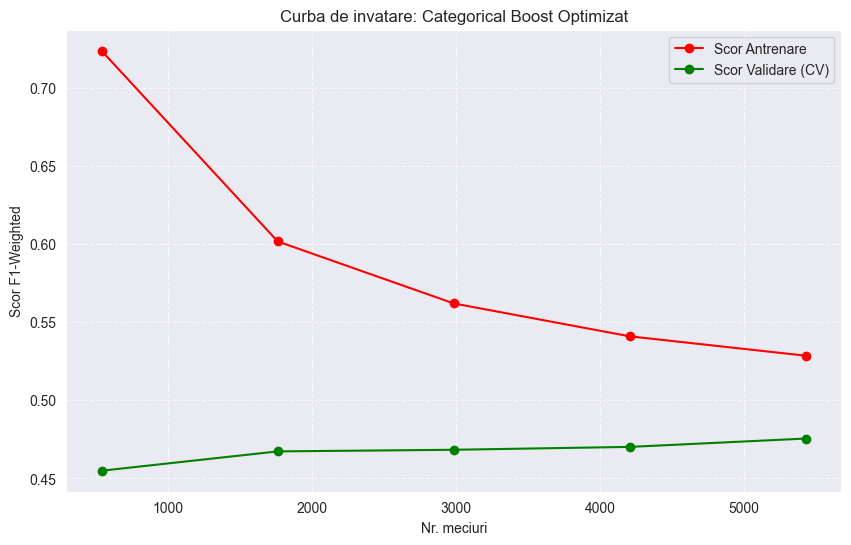

In [54]:
plot_learning_curve(best_catB, X_train_scaled, y_train, "Curba de invatare: Categorical Boost Optimizat")


In curba de invatare de mai sus, putem observa o diferenta mare intre cele 2 score-uri, rezultand overfitting.
Din nou, datele nu sunt suficiente in cazul egalului, modelul nu stie exact.

## 5. Xtreme Gradient Boost

Fitting 5 folds for each of 512 candidates, totalling 2560 fits
              precision    recall  f1-score   support

   Gazde (0)       0.53      0.81      0.64      1006
    Egal (1)       0.33      0.06      0.10       558
 Oaspeti (2)       0.51      0.47      0.49       699

    accuracy                           0.52      2263
   macro avg       0.46      0.44      0.41      2263
weighted avg       0.47      0.52      0.46      2263



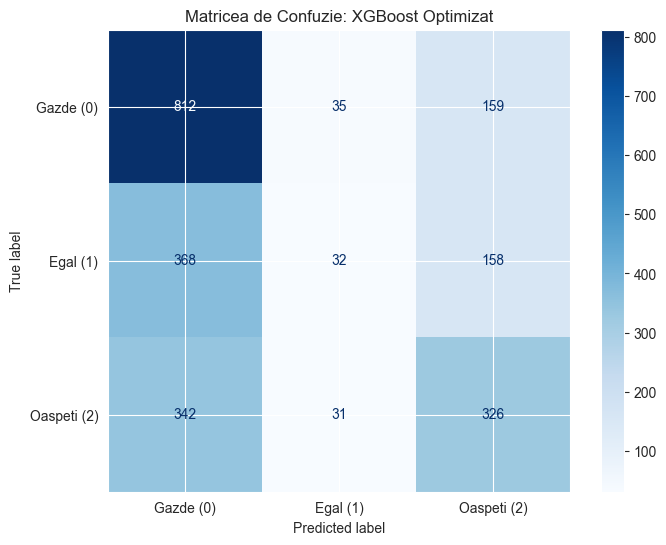

Total Accuracy: 0.52
Total Precision: 0.47
Total Recall: 0.52
Total F1-score: 0.46
Total AUC-ROC: 0.65


In [55]:
xgb_grid = {
    "n_estimators": [100, 300],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "gamma": [0, 0.1],
    "reg_alpha": [0, 0.1],
    "reg_lambda": [1, 1.5],
    "scale_pos_weight": [1, 2],
}

xgb_base = XGBClassifier(
    random_state=10,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    use_label_encoder=False,
    n_jobs=-1,
)

grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_grid,
    cv=5,
    scoring="f1_weighted",
    verbose=1,
    n_jobs=-1,
)

grid_search_xgb.fit(X_train_scaled, y_train)
best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb_opt = best_xgb.predict(X_test_scaled)
y_probs_xgb_opt = best_xgb.predict_proba(X_test_scaled)

acc_xgb_opt = accuracy_score(y_test, y_pred_xgb_opt)
prec_xgb_opt = precision_score(y_test, y_pred_xgb_opt, average='weighted')
rec_xgb_opt = recall_score(y_test, y_pred_xgb_opt, average='weighted')
f1_xgb_opt = f1_score(y_test, y_pred_xgb_opt, average='weighted')
auc_roc_xgb_opt = roc_auc_score(y_test, y_probs_xgb_opt, multi_class='ovr', average='weighted')

print(classification_report(y_test, y_pred_xgb_opt, target_names=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)']))

cm_xgb_opt = confusion_matrix(y_test, y_pred_xgb_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_opt, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
ax.set_title("Matricea de Confuzie: XGBoost Optimizat")
plt.show()

print(f"Total Accuracy: {acc_xgb_opt:.2f}")
print(f"Total Precision: {prec_xgb_opt:.2f}")
print(f"Total Recall: {rec_xgb_opt:.2f}")
print(f"Total F1-score: {f1_xgb_opt:.2f}")
print(f"Total AUC-ROC: {auc_roc_xgb_opt:.2f}")

Acuratetea, recall-ul si f1-score fata de celelalte modele, deoarece proportia pe egaluri este mai mica.

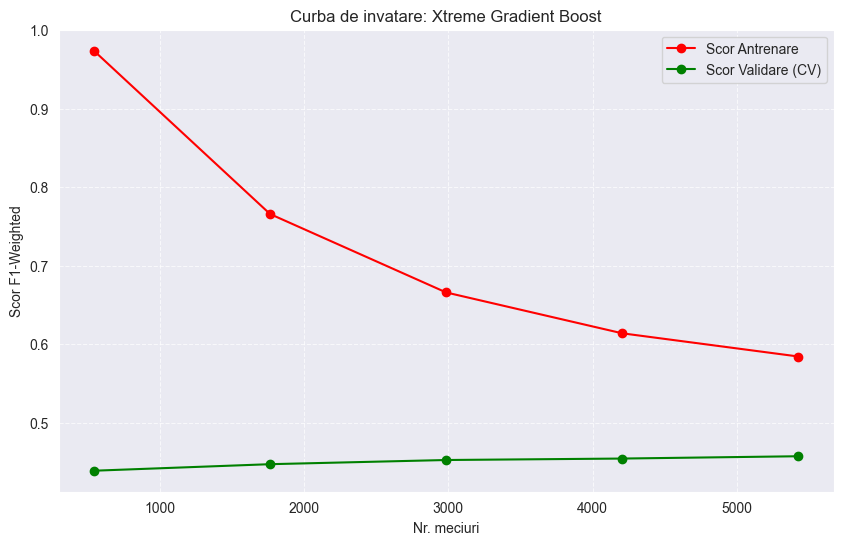

In [56]:
plot_learning_curve(best_xgb, X_train_scaled, y_train, "Curba de invatare: Xtreme Gradient Boost")


Graficul de mai sus sugereaza underfitting, deoarece curba de antrebare scade foarte repede si va converge cu cea de testare.

### Analiza comparativa intre modelele optimizate

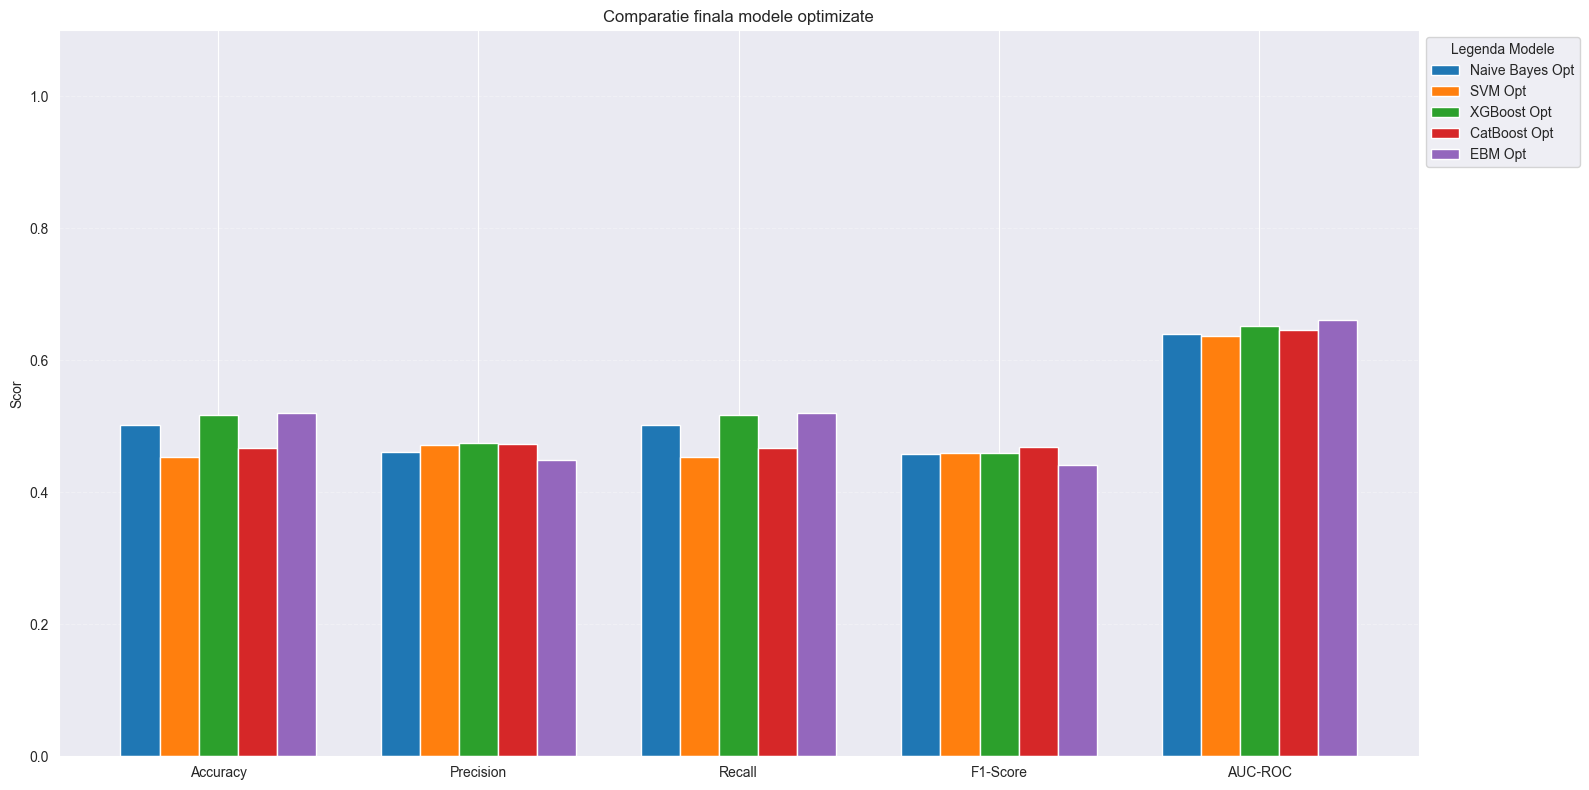

In [57]:
models_data_opt = {
    'Naive Bayes Opt':   [acc_nb_opt, prec_nb_opt, rec_nb_opt, f1_nb_opt, auc_roc_nb_opt],
    'SVM Opt':           [acc_svm_opt, prec_svm_opt, rec_svm_opt, f1_svm_opt, auc_roc_svm_opt],
    'XGBoost Opt':       [acc_xgb_opt, prec_xgb_opt, rec_xgb_opt, f1_xgb_opt, auc_roc_xgb_opt],
    'CatBoost Opt':      [acc_catB_opt, prec_catB_opt, rec_catB_opt, f1_catB_opt, auc_roc_catB_opt],
    'EBM Opt':           [acc_ebm_opt, prec_ebm_opt, rec_ebm_opt, f1_ebm_opt, auc_roc_ebm_opt],
}

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metric_names))
total_models_opt = len(models_data_opt)
width = 0.15

fig, ax = plt.subplots(figsize=(16, 8))
for i, (model_name, scores) in enumerate(models_data_opt.items()):
    offset = (i - total_models_opt/2) * width + width/2
    ax.bar(x + offset, scores, width, label=model_name)

ax.set_ylabel('Scor')
ax.set_title('Comparatie finala modele optimizate')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legenda Modele")
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Cele mai bune top 3 modele optimizate

In [58]:
df_results_opt = pd.DataFrame.from_dict(models_data_opt, orient='index', columns=metric_names)
df_results_opt['Weighted_Score'] = (
    df_results_opt['Accuracy'] * weights['Accuracy'] +
    df_results_opt['Precision'] * weights['Precision'] +
    df_results_opt['Recall'] * weights['Recall'] +
    df_results_opt['F1-Score'] * weights['F1-Score'] +
    df_results_opt['AUC-ROC'] * weights['AUC-ROC']
)
top_3_final = df_results_opt.sort_values(by='Weighted_Score', ascending=False).head(3)

print("Top 5 :")
display(top_3_final[['Weighted_Score', 'F1-Score', 'Accuracy', 'AUC-ROC','Recall','Precision']])

Top 5 :


,Weighted_Score,F1-Score,Accuracy,AUC-ROC,Recall,Precision
XGBoost Opt,0.501225,0.45970,0.517013,0.652474,0.517013,0.474284
EBM Opt,0.492340,0.44189,0.520548,0.660761,0.520548,0.448775
Naive Bayes Opt,0.492243,0.45802,0.502430,0.640454,0.502430,0.460924


### Cele mai bune top 3 modele dintre toate:

In [59]:
models_data_all = {**models_data, **models_data_opt}

df_results_all = pd.DataFrame.from_dict(models_data_all, orient='index', columns=metric_names)
df_results_all['Weighted_Score'] = (
    df_results_all['Accuracy'] * weights['Accuracy'] +
    df_results_all['Precision'] * weights['Precision'] +
    df_results_all['Recall'] * weights['Recall'] +
    df_results_all['F1-Score'] * weights['F1-Score'] +
    df_results_all['AUC-ROC'] * weights['AUC-ROC']
)
display(df_results_all[['Weighted_Score', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']]
        .sort_values('Weighted_Score', ascending=False))


,Weighted_Score,Accuracy,Precision,Recall,F1-Score,AUC-ROC
EBM,0.510437,0.524083,0.557400,0.524083,0.443359,0.660547
SVM,0.501539,0.506407,0.625214,0.506407,0.424228,0.608233
XGBoost Opt,0.501225,0.517013,0.474284,0.517013,0.459700,0.652474
EBM Opt,0.492340,0.520548,0.448775,0.520548,0.441890,0.660761
Naive Bayes,0.492244,0.502430,0.460924,0.502430,0.458020,0.640466
Naive Bayes Opt,0.492243,0.502430,0.460924,0.502430,0.458020,0.640454
CatBoost Opt,0.486644,0.467521,0.473846,0.467521,0.468440,0.645582
CatBoost,0.484758,0.491383,0.448895,0.491383,0.456177,0.629686
SVM Opt,0.477484,0.454264,0.471545,0.454264,0.460114,0.637139
XGBoost,0.470546,0.470614,0.436310,0.470614,0.444536,0.625700


#### Ce putem observa in urma tuturor modelelor?
- modificarea hiperparametrilor nu garanteaza rezultate, mai bune. In plus, prin modificare, am ajuns in multe cazuri de overfitting sau underfitting.
- top 3 au acuratete de 50% si precizie mare, ceea ce reprezinta un progres.
- Chiar daca per-total nu par rezultate bune, am incercat pe un dataset mai special , despre fotbal, care ma pasioneaza si am anumite cunostinte. In plus, datele detinute de mine nu se compara cu cele pe care le au de exemplu companiile specializate.

Mai departe voi analiza top 3 modele cu cele mai bune performante dintre toate cele 14, nu neaparatat cele optimizate.Acestea sunt:
1. Explainable Boosting Machine
2. Support Vector Machine
3. XTreme Gradient Boost optimizat

## Analiza SHAP

### 1. Explainable Boosting Machine - SHAP

Ca si explainer vom folosi un _Tree Explainer_, fiind mai performant.

In [63]:
import shap
background_size =min(30, len(X_train_scaled))
xgb_base.fit(X_train_scaled, y_train)
background = pd.DataFrame(X_train_scaled).sample(background_size, random_state=10)
explainer = shap.TreeExplainer(xgb_base)

Calculez valori shap pentru exemple din setul de date:

In [64]:
sample_size =min(50, len(X_test_scaled))
X_shap_sample = X_test_scaled[:sample_size].copy()

shap_values =explainer.shap_values(X_shap_sample)
expected_values =explainer.expected_value

print("Număr exemple explicate:", len(X_shap_sample))
print("Tip obiect shap_values:", type(shap_values))

Număr exemple explicate: 50
Tip obiect shap_values: <class 'numpy.ndarray'>


Normalizam formatul iesirii:
forma ar fi : avem 3 clase de clasificare, pe 50 de exemple, iar coloanele sunt 14 din cele 15 totale.

In [65]:
class_names = ['Home', 'Drow', 'Away']
if isinstance(shap_values, list):
    shap_values_array = np.array(shap_values)
else:
    shap_values_array = np.array(shap_values)
    if shap_values_array.ndim == 3:
        # posibil format: (n_samples, n_features, n_classes)
        if shap_values_array.shape[0] == len(X_shap_sample) and shap_values_array.shape[2] == len(class_names):
            shap_values_array = np.transpose(shap_values_array, (2, 0, 1))
    elif shap_values_array.ndim == 2:
        shap_values_array = shap_values_array[np.newaxis, :, :]

print("Forma shap_values_array:", shap_values_array.shape)

Forma shap_values_array: (3, 50, 14)


#### Interpretare globala :
Observam importanta medie absoluta la toate caracteristicile.

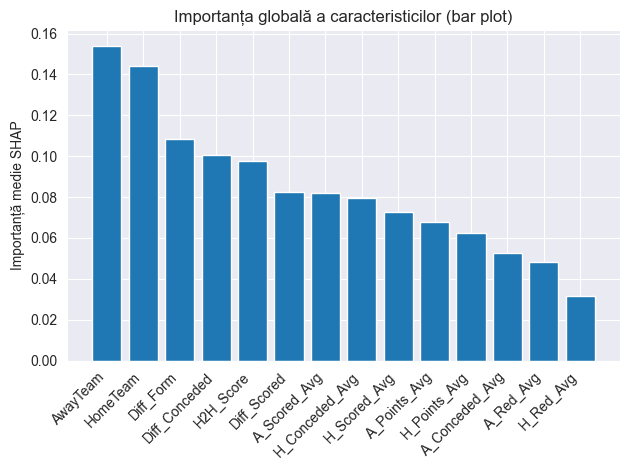

,feature,mean_abs_shap
1,AwayTeam,0.153878
0,HomeTeam,0.144259
11,Diff_Form,0.108451
13,Diff_Conceded,0.100601
10,H2H_Score,0.097518
12,Diff_Scored,0.082354
3,A_Scored_Avg,0.081785
4,H_Conceded_Avg,0.079678
2,H_Scored_Avg,0.072885
7,A_Points_Avg,0.067795


In [66]:
global_importance = np.mean(np.abs(shap_values_array), axis=(0, 1))
feature_cols = X.columns.tolist()
global_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": global_importance
}).sort_values(by="mean_abs_shap", ascending=False)

plt.figure()
plt.bar(global_importance_df["feature"], global_importance_df["mean_abs_shap"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importanță medie SHAP")
plt.title("Importanța globală a caracteristicilor (bar plot)")
plt.tight_layout()
plt.show()

global_importance_df

Cum era de asteptat, influenteaza foarte mult daca echipa este in deplasare sau nu. Totodata, un rezultat placut este faptul ca difernta dintre echipe la acel moment(forma) conteaza si ea foarte mult.
Din pacate, rezultatele directe nu conteaza asa mult cum ne asteptam si media golurilor la fel.
Media cartonaselor medii conteaza cel mai putin, deoarece nu ne asteptam ca in fiecare meci de fotbal sa existe un cartonas rosu.

Pentru summary plot, vom alege o singura clasa pe rand ca sa generam graficul.

1. Pentru rezultatul de victorie gazda

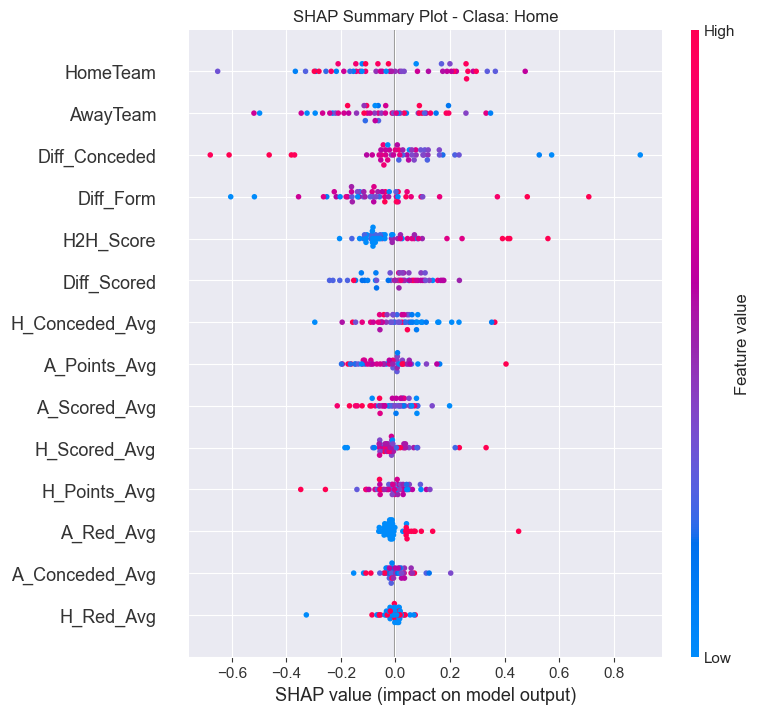

In [67]:
clasa_vizualizata = 0
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_array[clasa_vizualizata],
    X_shap_sample,
    feature_names = feature_cols,
    show=False
)
plt.title(f"SHAP Summary Plot - Clasa: {class_names[clasa_vizualizata]}")
plt.show()

Surprinzator conteaza foarte mult diferenta de goluri primite, mai ales in mod negativ.
Diferenta de forma influenteaza in mod negativ mult.
Cu cat importanta scade, valoriile incearca sa nu influenteze output-ul.

2. Pentru rezultatul de egalitate:

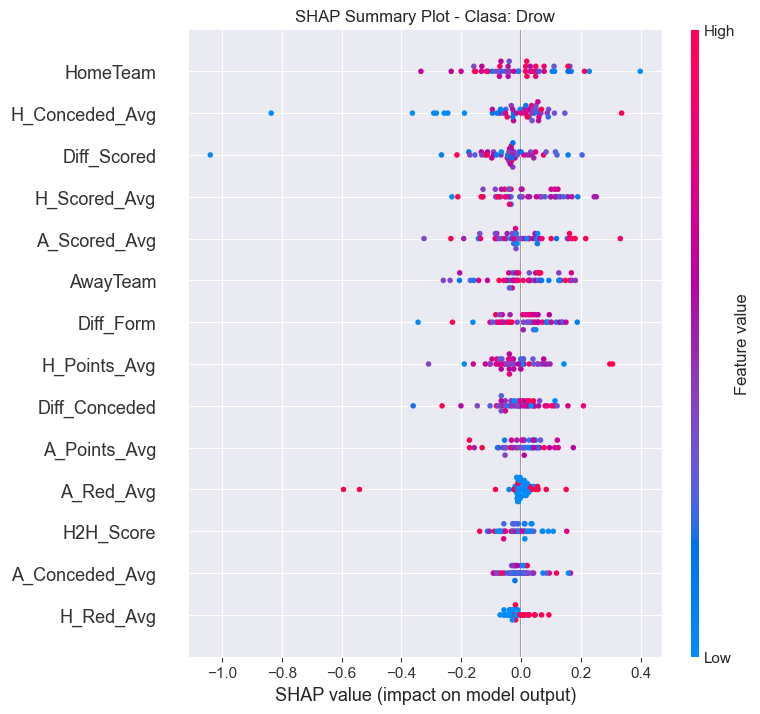

In [68]:
clasa_vizualizata = 1
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_array[clasa_vizualizata],
    X_shap_sample,
    feature_names = feature_cols,
    show=False
)
plt.title(f"SHAP Summary Plot - Clasa: {class_names[clasa_vizualizata]}")
plt.show()

In urma acestui grafic, ne putem da oarecum seama motivul pentru care exista rezultate slabe la egal. Fata de primul grafic, unde impactul pe output este oarecum simetric, la egalitate impactul este in mare parte pe valori negative.

3. Pentru rezultatul de victorie a oaspetilor:

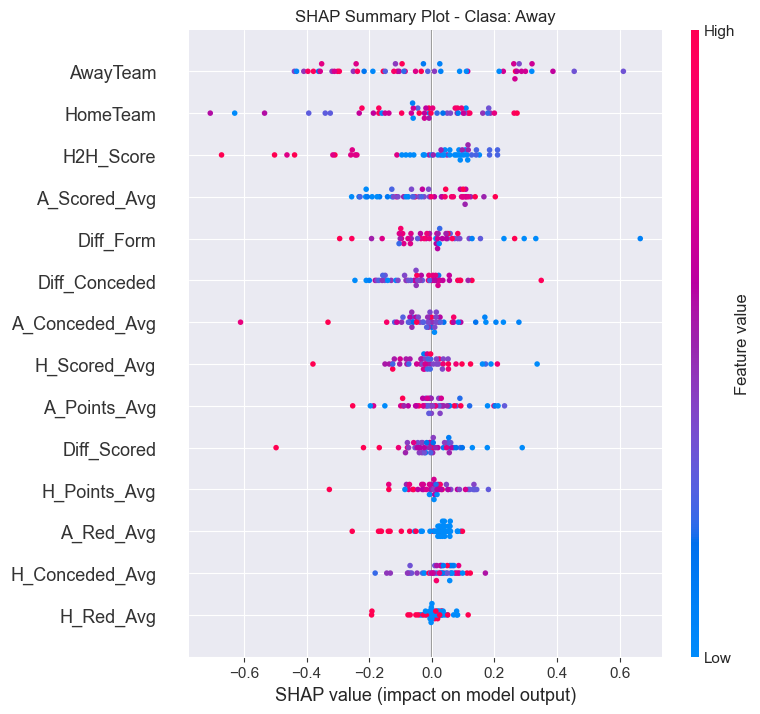

In [69]:
clasa_vizualizata = 2
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_array[clasa_vizualizata],
    X_shap_sample,
    feature_names = feature_cols,
    show=False
)
plt.title(f"SHAP Summary Plot - Clasa: {class_names[clasa_vizualizata]}")
plt.show()

Rezultatul de lose pentru gazde este simetric fata de impact, asemanator cu rezultatul de victorie.
Surprinzator, aici rezultatele directe conteaza pe locul 3 si alte statistici relevante pentru echipa care joaca in deplasare.

#### Explicație locală
Aceasta analiza ne arata cum se comporta modelul in cadrul unei predictii:

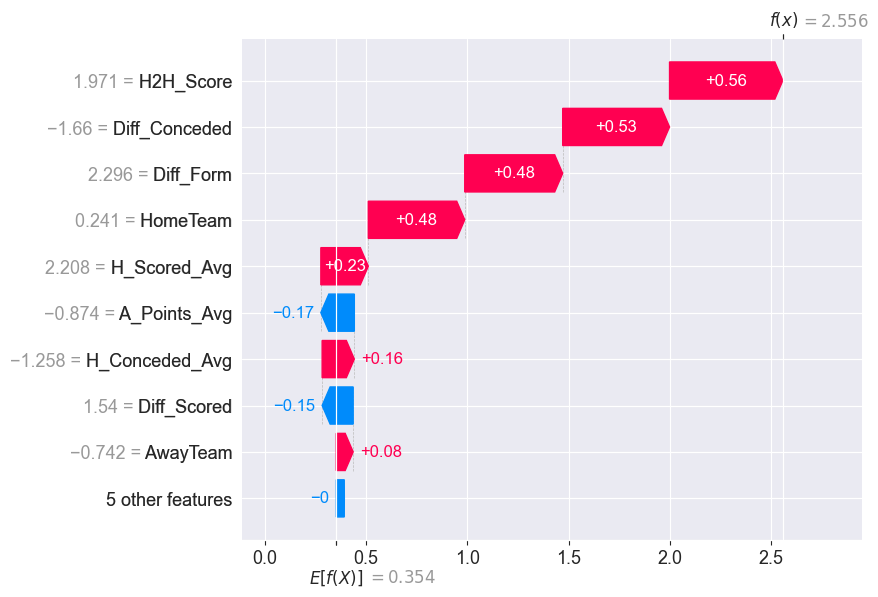

In [81]:
X_df = pd.DataFrame(X_shap_sample, columns=X_train.columns)
explanation_obj = explainer(X_df)
shap.plots.waterfall(explanation_obj[0, :, 0])

In graficul de tip waterfall de mai sus putem observa cele mai influente atribute in cazul predictiei pentru victoria gazdelor.
Valoarea de baza reprezinta media tuturor, catre care tinde predictia pentru aceasta clasa, fiind de 0.354.
Ce este in dreapta, sus, in cazul nostru 2.556 reprezinta suma dintre media valoarea de baza si valorile shap din stanga, fiind predictia finala.
Putem observa ca H2H_score, Diff_conceded, diff_form, home_team au facut modelul sa se indeparteze destul de mult de medie pe acest exmeplu

In [74]:
shap.initjs()
shap.plots.force(explanation_obj[0, :, 0])

Force plot are aceeasi semnificatie cu graficul de tipul waterfall. Se pastreaza consistent culoarea atributelor, cele colorate in albastru 'slabesc' modelul, iar culoarea rosie il ajuta sa prezica un rezultat mai bun.

#### Scatter plot
O sa facem scatter plot pentru urmatoarele features:
- H2H
- Diff_form
- HomeTeam

Altfel spus, dorim sa vedem cu adevarat valorile acestor atribute si cat de mult influenteaza individual.

Scatter plot pentru H2H:

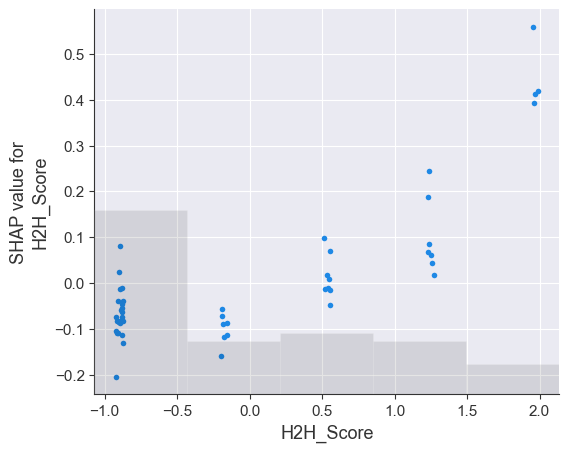

In [88]:
h2h_index = list(X_train.columns).index("H2H_Score")
shap.plots.scatter(explanation_obj[:, h2h_index, 0])

Influenta H2H_score este destul de variata, atat negativ cat si pozitiv, iar cu cat valoarea atributului este mai mare, cu atata influenteaza mai mult valoarea shap. Valorile mai mici, care sunt mai multe , imping modelul in jos, dar mai putin, doar cu -0.2 .

Scatter plot pentru _diferenta de forma_:

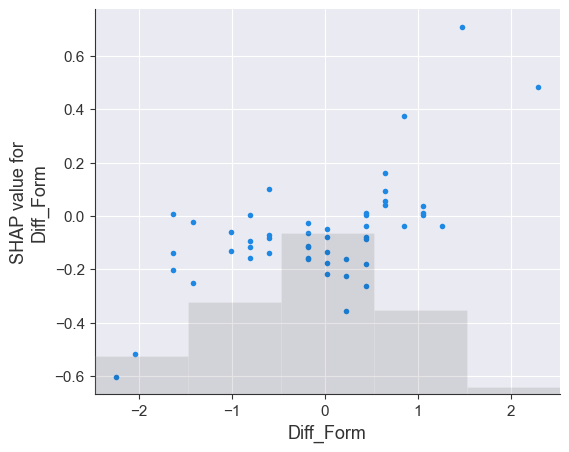

In [91]:
diff_form_index = list(X_train.columns).index("Diff_Form")
shap.plots.scatter(explanation_obj[:, diff_form_index, 0])

Mai sus este reprezentata diferenta de forma. Putem observa ca acest atribut nu prea conteaza, deoarece aceasta diferenta este mica, multe in intervalul [-1,1]. Din aceasta observatie rezulta ca toate echipele sunt echilibrate ca forma si valoarea shap este aproximativ situata in intervalul [-0.2, 0.2].

Scatter plot pentru echipa gazda:


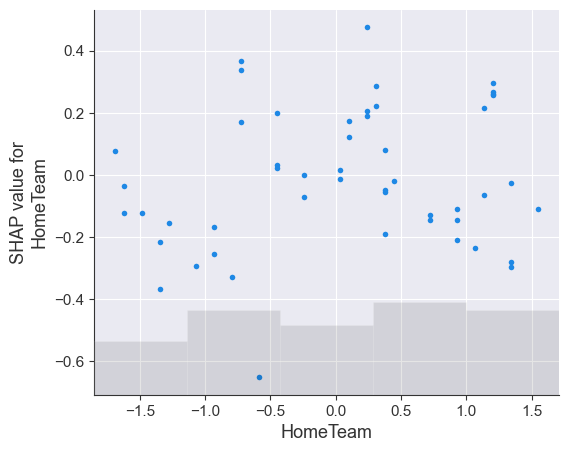

In [92]:
home_team_index = list(X_train.columns).index("HomeTeam")
shap.plots.scatter(explanation_obj[:, home_team_index, 0])

In graficul de mai sus, este subliniata importanta terenului propriu. Id-ul echipei este si negativ datorata faptului ca am folosit scalarea, deoarece nu am dorit ca un id mare sa influenteze mai mult.
Valuarea shap este stabilizata in jurul valorii de 0.

#### Cele mai bune predictii conform analizei shap sunt :
- H2H_Score (din graficul waterfall).
- Diff_Conceded
- Diff_Form

Pentru un exemplu concret din clasa 0 : castiga gazdele.
- valoarea de baza este 0.354. Predictia este impinsa pozitiv datorita lui H2H_score si diff_conceded. Rezulta faptul ca meciurile directe si diferenta dintre nr. de goluri primite conteaza.
- Pe partea negativa, au influentat A_Points_Avg si Diff_Score.

### 2. Support Vector Machine - SHAP

Ca si explainer vom folosi un _KernelExplainer_, fiind mai performant si cu un numar mic de exemple din cauza timpului de executie.

In [96]:
background_size =min(30, len(X_train_scaled))
svm_ml.fit(X_train_scaled, y_train)
background = pd.DataFrame(X_train_scaled).sample(background_size, random_state=10)
explainer = shap.KernelExplainer(svm_ml.predict_proba, background)

Calculez valori shap pentru exemple din setul de date:

In [97]:
sample_size =min(10, len(X_test_scaled))
X_shap_sample = X_test_scaled[:sample_size].copy()

shap_values =explainer.shap_values(X_shap_sample)
expected_values =explainer.expected_value

print("Număr exemple explicate:", len(X_shap_sample))
print("Tip obiect shap_values:", type(shap_values))

  0%|          | 0/10 [00:00<?, ?it/s]

Număr exemple explicate: 10
Tip obiect shap_values: <class 'numpy.ndarray'>


In [98]:
class_names = ['Home', 'Drow', 'Away']
if isinstance(shap_values, list):
    shap_values_array = np.array(shap_values)
else:
    shap_values_array = np.array(shap_values)
    if shap_values_array.ndim == 3:
        # posibil format: (n_samples, n_features, n_classes)
        if shap_values_array.shape[0] == len(X_shap_sample) and shap_values_array.shape[2] == len(class_names):
            shap_values_array = np.transpose(shap_values_array, (2, 0, 1))
    elif shap_values_array.ndim == 2:
        shap_values_array = shap_values_array[np.newaxis, :, :]

print("Forma shap_values_array:", shap_values_array.shape)

Forma shap_values_array: (3, 10, 14)


#### Interpretare globala :
Observam importanta medie absoluta la toate caracteristicile.

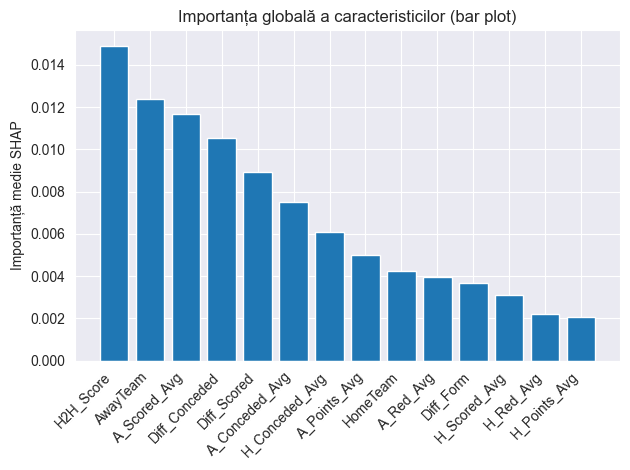

,feature,mean_abs_shap
10,H2H_Score,0.014888
1,AwayTeam,0.012377
3,A_Scored_Avg,0.011660
13,Diff_Conceded,0.010531
12,Diff_Scored,0.008934
5,A_Conceded_Avg,0.007523
4,H_Conceded_Avg,0.006082
7,A_Points_Avg,0.005005
0,HomeTeam,0.004225
9,A_Red_Avg,0.003950


In [99]:
global_importance = np.mean(np.abs(shap_values_array), axis=(0, 1))
feature_cols = X.columns.tolist()
global_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": global_importance
}).sort_values(by="mean_abs_shap", ascending=False)

plt.figure()
plt.bar(global_importance_df["feature"], global_importance_df["mean_abs_shap"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importanță medie SHAP")
plt.title("Importanța globală a caracteristicilor (bar plot)")
plt.tight_layout()
plt.show()

global_importance_df

Ca si importanta globala, se observa ca H2H este cu cea mai mare influenta, fata de AwayTeam care era la EBM. Totusi in cazul acestui model, AwayTeam este a 2-a cea mai importanta caracteristica.

Pentru summary plot, vom alege o singura clasa pe rand ca sa generam graficul.


1. Pentru rezultatul de victorie gazda

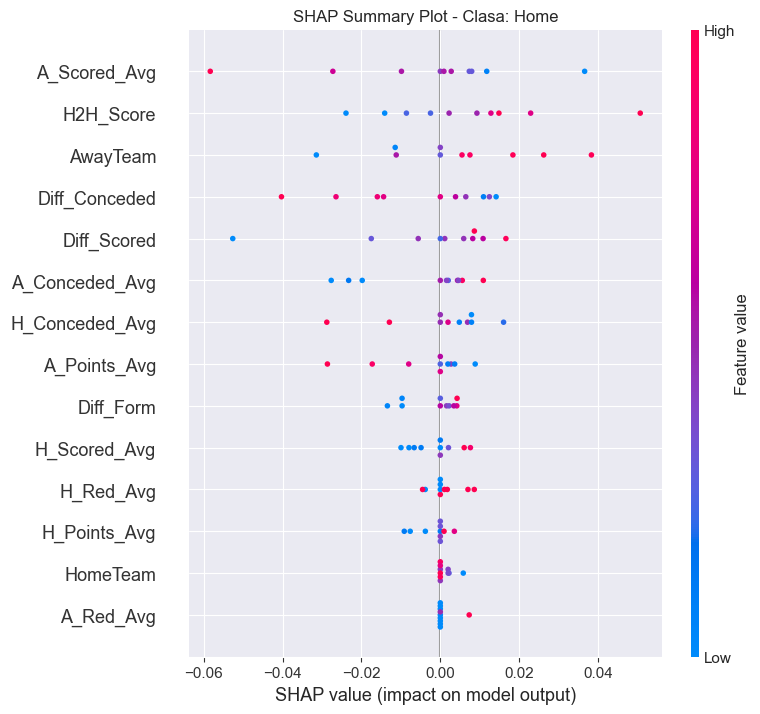

In [100]:
clasa_vizualizata = 0
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_array[clasa_vizualizata],
    X_shap_sample,
    feature_names = feature_cols,
    show=False
)
plt.title(f"SHAP Summary Plot - Clasa: {class_names[clasa_vizualizata]}")
plt.show()

2. Pentru rezultatul de victorie gazda

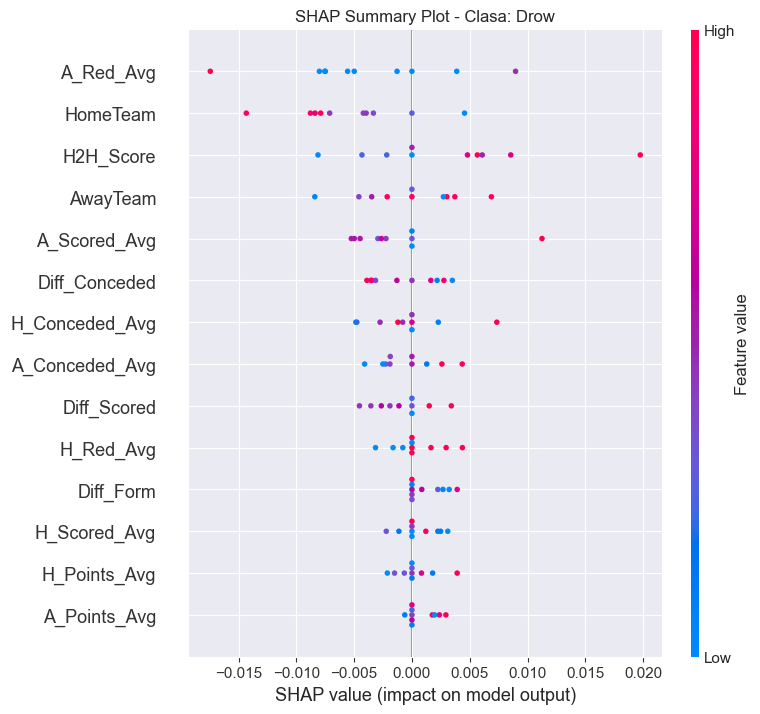

In [101]:
clasa_vizualizata = 1
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_array[clasa_vizualizata],
    X_shap_sample,
    feature_names = feature_cols,
    show=False
)
plt.title(f"SHAP Summary Plot - Clasa: {class_names[clasa_vizualizata]}")
plt.show()

3. Pentru rezultatele de victorie a echipei oaspete

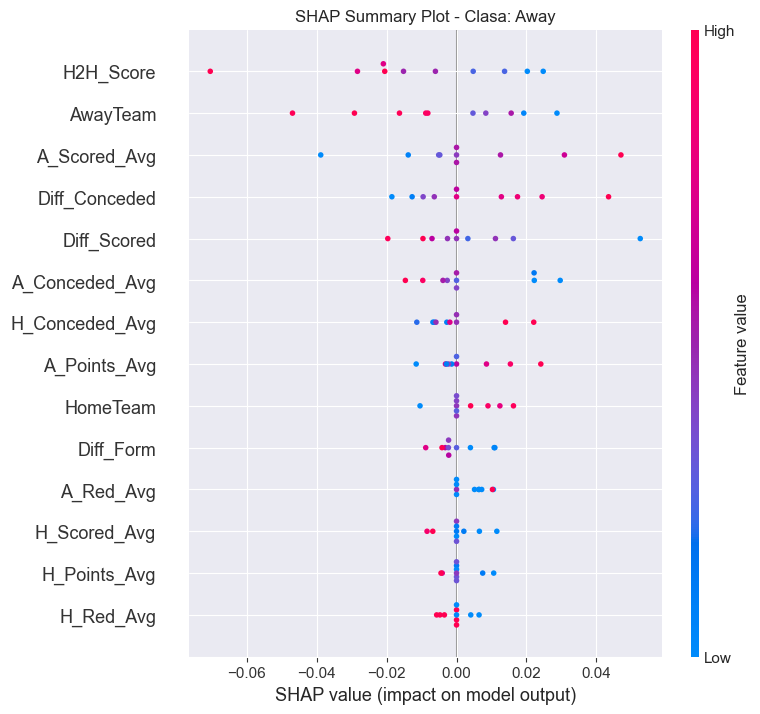

In [102]:
clasa_vizualizata = 2
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_array[clasa_vizualizata],
    X_shap_sample,
    feature_names = feature_cols,
    show=False
)
plt.title(f"SHAP Summary Plot - Clasa: {class_names[clasa_vizualizata]}")
plt.show()

In urma analizei pentru fiecare clasa in parte rezulta urmatoarele:
- H2H_score isi pastreaza calitatea de cel mai bun atribut, fiind primul sau al doilea in fiecare clasa ca si impact.
- Surprinzator, la egalitate, cel mai mare impact il are media cartonaselor rosii a oaspetilor.
- Ca la modelul anterior, AwayTeam si HomeTeam au o putere de decizie mare. Aceast aspect confirma etapa de analiza exploratorie a datelor si etapa de testare a modelelor default.

#### Explicație locală
Aceasta analiza ne arata cum se comporta modelul in cadrul unei predictii:

  0%|          | 0/10 [00:00<?, ?it/s]

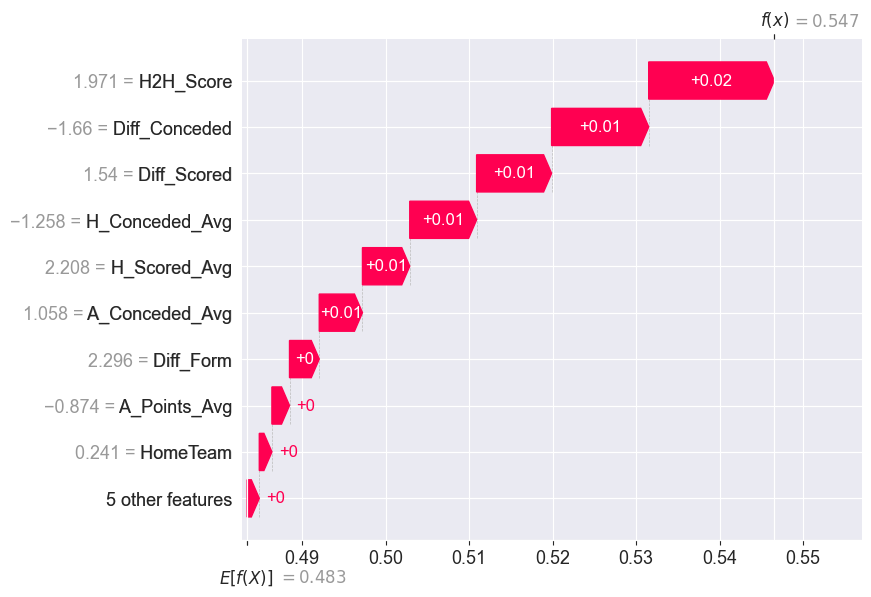

In [103]:
X_df = pd.DataFrame(X_shap_sample, columns=X_train.columns)
explanation_obj = explainer(X_df)
shap.plots.waterfall(explanation_obj[0, :, 0])

In diagrama waterfall se observa urmatoarele :
- valoarea de baza este de 0.483, mai ridicata decat la modelul precedent.
- predictia finala este mult mai scazuta, doar de 0.547. In plus, se observa din grafic faptul ca influtenta in sus a atributelor este foarte mica,de exemplu +0.02.
- Valoarea de baza este un numar acceptabil, deoarece modelul nu este tras in jos.

In [104]:
shap.initjs()
shap.plots.force(explanation_obj[0, :, 0])

Pentru partea de analiza a 3 caracteristici, am luat in considerare sa iau aceleasi la toate modelele. In plus,consider ca urmatoarele rezultate si rezultatele anterioare de la analiza globala sunt influentate si de numarul de exemple rulate de model.

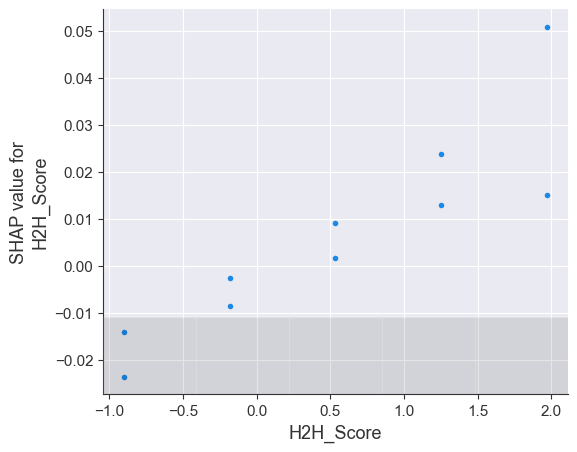

In [105]:
h2h_index = list(X_train.columns).index("H2H_Score")
shap.plots.scatter(explanation_obj[:, h2h_index, 0])

Atributul de H2H influenteaza valoarea H2H mai mult in partea pozitiva.

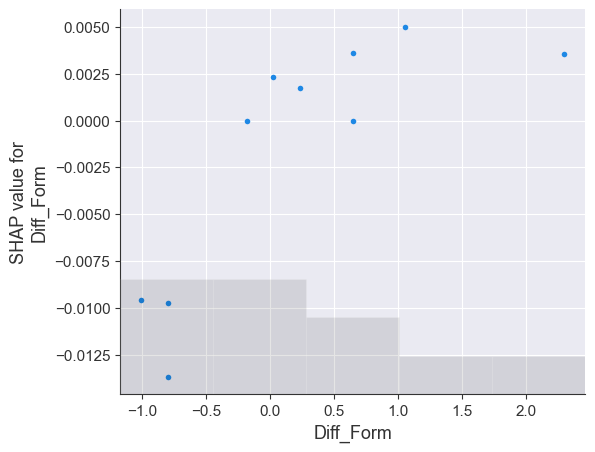

In [106]:
diff_form_index = list(X_train.columns).index("Diff_Form")
shap.plots.scatter(explanation_obj[:, diff_form_index, 0])

Atributul de H2H influenteaza valoarea Diff_form mai mult in partea pozitiva.

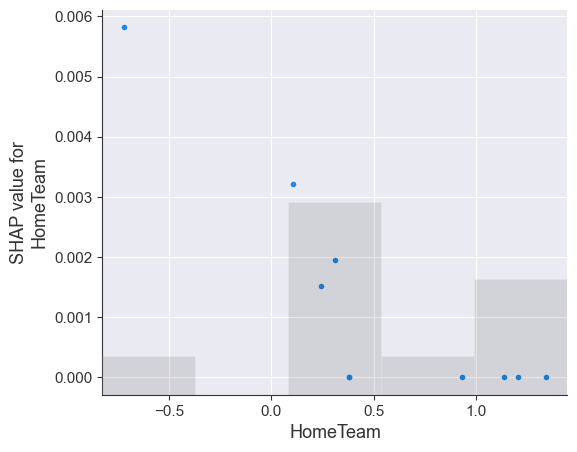

In [107]:
home_team_index = list(X_train.columns).index("HomeTeam")
shap.plots.scatter(explanation_obj[:, home_team_index, 0])

Interesant pentru _HomeTeam_ este faptul ca nu impinge in jos deloc, ceea ce se putea vedea din diagrama waterfall.

#### Cele mai bune predictii conform analizei shap sunt :
- H2H_Score
- Diff_Conceded
- AwayTeam

Pentru un exemplu concret din clasa 0 : castiga gazdele.
- valoarea de baza este 0.483. Predictia este impinsa pozitiv datorita lui H2H_score si diff_conceded. Rezulta faptul ca meciurile directe si diferenta dintre nr. de goluri primite conteaza.
- Pe partea negativa, valorile Shap nu sunt impinse in jos de nicio caracteristica, ceea ce poate reprezenta un avantaj, insa si cresterea este mica.Poate o scadere ar fi impulsionat o crestere mai mare.

### 3. XTreme Gradient Boost optimizat - SHAP

Ca si explainer vom folosi un _TreeExplainer_, fiind mai performant.

In [111]:
background_size =min(30, len(X_train_scaled))
best_xgb.fit(X_train_scaled, y_train)
background = pd.DataFrame(X_train_scaled).sample(background_size, random_state=10)
explainer = shap.TreeExplainer(best_xgb)

In [115]:
sample_size =min(500, len(X_test_scaled))
X_shap_sample = X_test_scaled[:sample_size].copy()

shap_values =explainer.shap_values(X_shap_sample)
expected_values =explainer.expected_value

print("Număr exemple explicate:", len(X_shap_sample))
print("Tip obiect shap_values:", type(shap_values))

Număr exemple explicate: 500
Tip obiect shap_values: <class 'numpy.ndarray'>


In [116]:
class_names = ['Home', 'Drow', 'Away']
if isinstance(shap_values, list):
    shap_values_array = np.array(shap_values)
else:
    shap_values_array = np.array(shap_values)
    if shap_values_array.ndim == 3:
        # posibil format: (n_samples, n_features, n_classes)
        if shap_values_array.shape[0] == len(X_shap_sample) and shap_values_array.shape[2] == len(class_names):
            shap_values_array = np.transpose(shap_values_array, (2, 0, 1))
    elif shap_values_array.ndim == 2:
        shap_values_array = shap_values_array[np.newaxis, :, :]

print("Forma shap_values_array:", shap_values_array.shape)

Forma shap_values_array: (3, 500, 14)


#### Interpretare globala :
Observam importanta medie absoluta la toate caracteristicile.

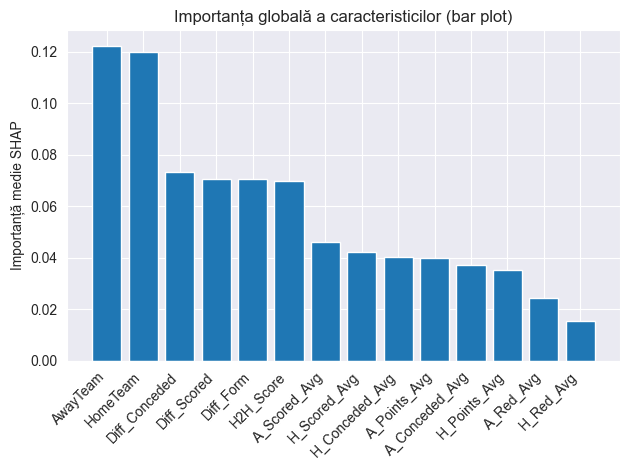

,feature,mean_abs_shap
1,AwayTeam,0.122162
0,HomeTeam,0.120025
13,Diff_Conceded,0.073314
12,Diff_Scored,0.070547
11,Diff_Form,0.070537
10,H2H_Score,0.069800
3,A_Scored_Avg,0.046206
2,H_Scored_Avg,0.042224
4,H_Conceded_Avg,0.040359
7,A_Points_Avg,0.039701


In [117]:
global_importance = np.mean(np.abs(shap_values_array), axis=(0, 1))
feature_cols = X.columns.tolist()
global_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": global_importance
}).sort_values(by="mean_abs_shap", ascending=False)

plt.figure()
plt.bar(global_importance_df["feature"], global_importance_df["mean_abs_shap"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importanță medie SHAP")
plt.title("Importanța globală a caracteristicilor (bar plot)")
plt.tight_layout()
plt.show()

global_importance_df

Interesant este faptul ca XTreme Gradient Boost optimizat vede la fel de important AwayTeam si HomeTeam. Altfel spus, nu conteaza daca o echipa este gazda sau oaspete.Apoi, diff_conceded conteaza si aici si este constant, rezultand faptul ca este o metrica buna pentru acest modeel.

Pentru summary plot, vom alege o singura clasa pe rand ca sa generam graficul.


1. Pentru rezultatul de victorie gazda

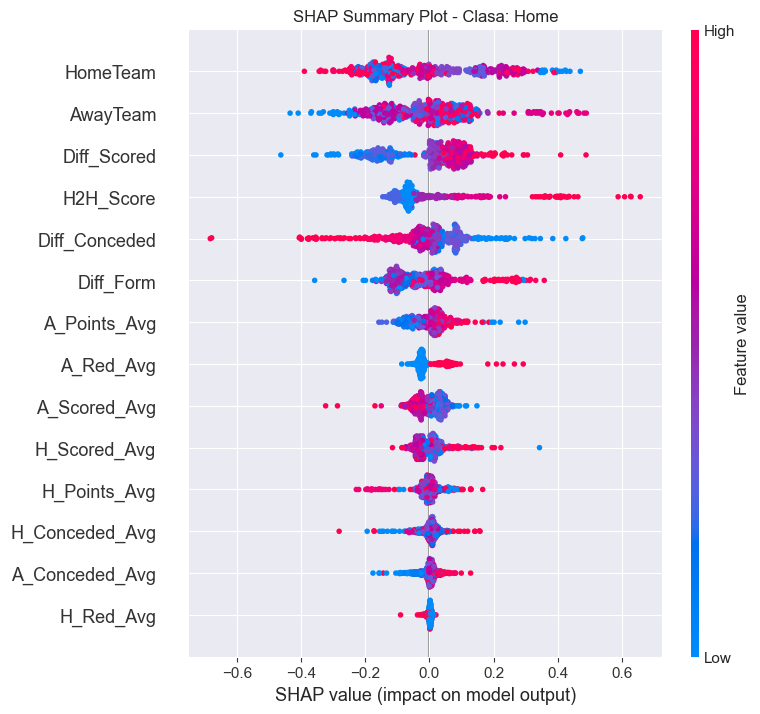

In [118]:
clasa_vizualizata = 0
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_array[clasa_vizualizata],
    X_shap_sample,
    feature_names = feature_cols,
    show=False
)
plt.title(f"SHAP Summary Plot - Clasa: {class_names[clasa_vizualizata]}")
plt.show()

2. Pentru rezultatul de egalitate

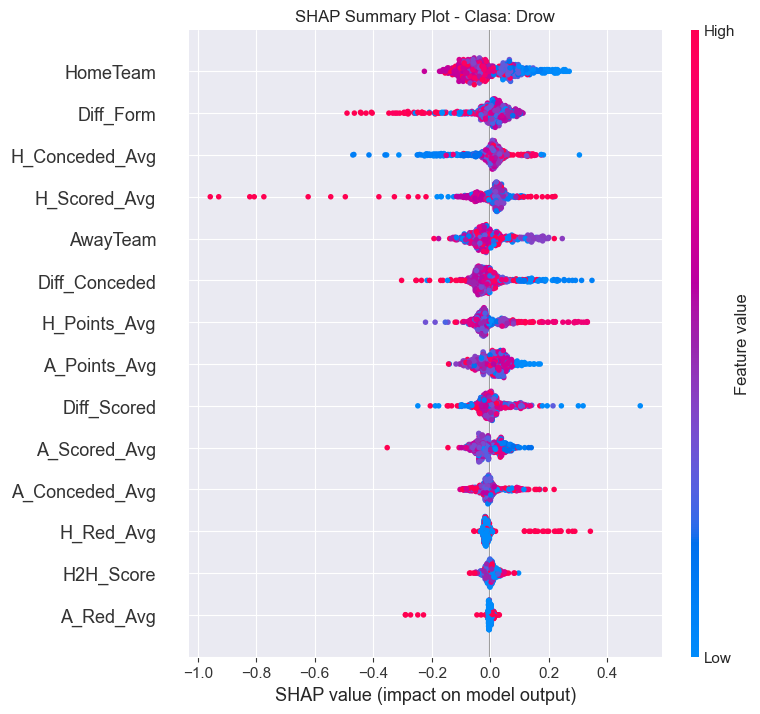

In [120]:
clasa_vizualizata = 1
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_array[clasa_vizualizata],
    X_shap_sample,
    feature_names = feature_cols,
    show=False
)
plt.title(f"SHAP Summary Plot - Clasa: {class_names[clasa_vizualizata]}")
plt.show()

3. Pentru rezultatul de victorie a oaspetilor

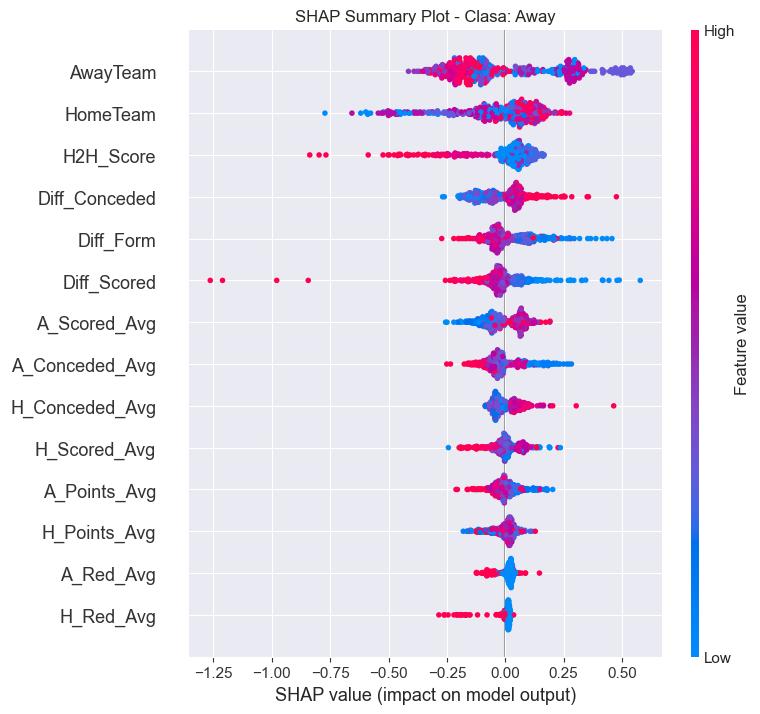

In [119]:
clasa_vizualizata = 2
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_array[clasa_vizualizata],
    X_shap_sample,
    feature_names = feature_cols,
    show=False
)
plt.title(f"SHAP Summary Plot - Clasa: {class_names[clasa_vizualizata]}")
plt.show()

Shap value in cazul clasei de victorie a gazdelor este echilibrat, simetric fata de toate atributele. Se poate observa o tentatie pozitiva. In rest, celelalte 2 clase reusesc mai mult sa atraga in jos shap value, impactul fiind negativ.

#### Explicație locală
Aceasta analiza ne arata cum se comporta modelul in cadrul unei predictii:

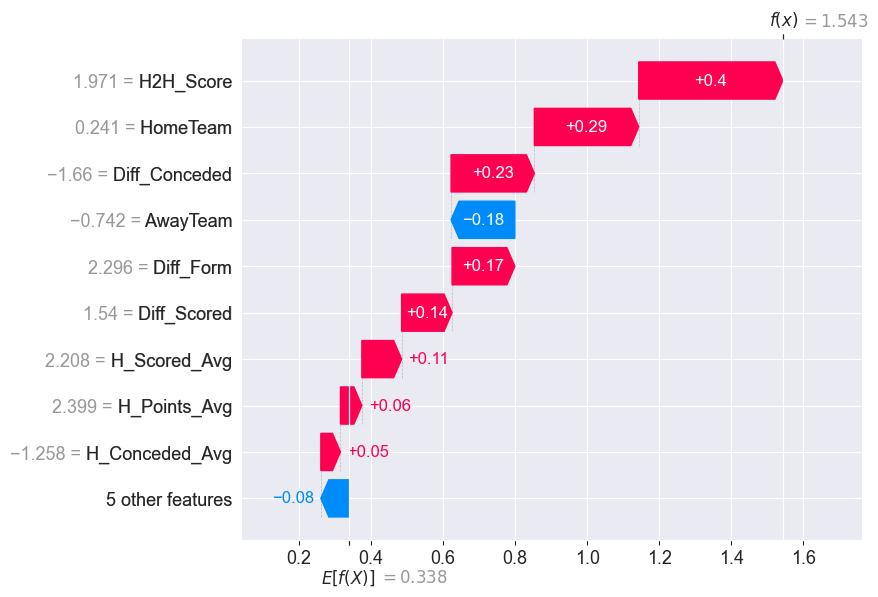

In [121]:
X_df = pd.DataFrame(X_shap_sample, columns=X_train.columns)
explanation_obj = explainer(X_df)
shap.plots.waterfall(explanation_obj[0, :, 0])

In diagrama waterfall se observa urmatoarele :
- valoarea de baza este de 0.338, mai ridicata decat la modelul precedent.
- predictia finala este mai echilibrata, intre predictia celor 2 modele anterioare, fiind 1.543. O influenta puternica o are si aici H2H_Score si Home_team.
- Modelul este putin tras in jos, in principiu de atributul AwayTeam.

In [122]:
shap.initjs()
shap.plots.force(explanation_obj[0, :, 0])

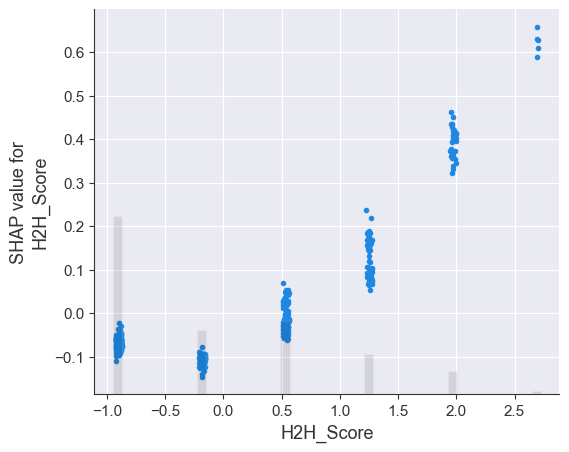

In [123]:
h2h_index = list(X_train.columns).index("H2H_Score")
shap.plots.scatter(explanation_obj[:, h2h_index, 0])

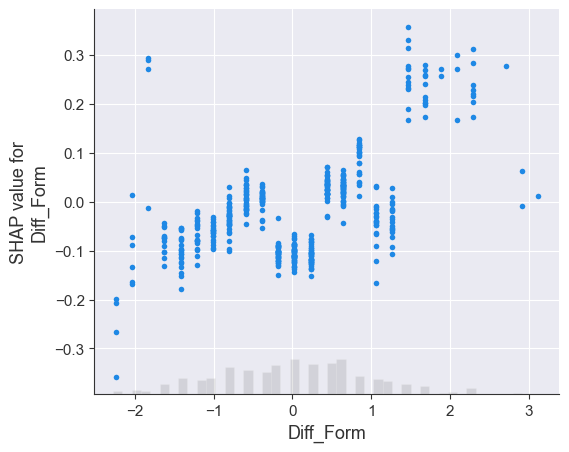

In [124]:
diff_form_index = list(X_train.columns).index("Diff_Form")
shap.plots.scatter(explanation_obj[:, diff_form_index, 0])

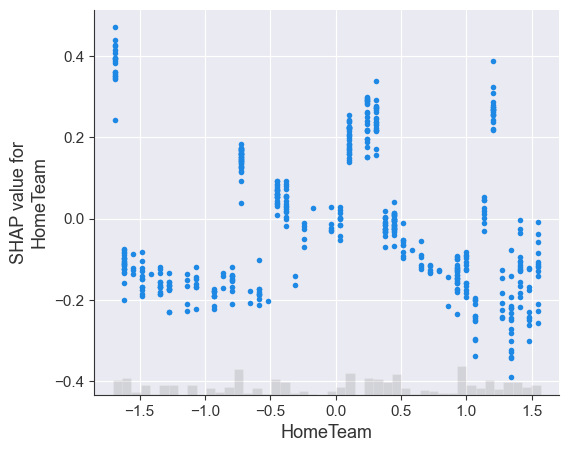

In [125]:
home_team_index = list(X_train.columns).index("HomeTeam")
shap.plots.scatter(explanation_obj[:, home_team_index, 0])

De remarcat este distributia exemplelor in cadrul acestui model, pe verticala. Asta se poate datora si din faptul ca numarul de exemple este mult mai mare fata de cele anterioare. H2H_score trace putin in jos shap_value, in rest doar in sus, dar odata ce creste H2H_score , asa sunt mai rare exemplele.
Valoarea shap in functie de caracteristica: 'Diferenta de forma' este usor pozitiva.


#### Cele mai bune predictii conform analizei shap sunt :
- H2H_Score
- Diff_Conceded
- HomeTeam

Pentru un exemplu concret din clasa 0 : castiga gazdele.
- valoarea de baza este 0.338. Predictia este impinsa pozitiv datorita lui H2H_score si HomeTeam. Rezulta faptul ca meciurile directe si cine e echipa gazda conteaza.
- Pe partea negativa, valorile Shap sunt impinse in jos cel mai mult de caracteristica: AwayTeam.